Interpreting the Perturbation Embedding Space

**Biological question:** How do ALS gene perturbations restructure GeneFormer V2's latent representation of disease-vulnerable motor neurons, and can embedding topology reveal mechanistic relationships between perturbed genes, disease states, and potential therapeutic trajectories?

---

## Scientific Rationale

generated GeneFormer V2 embeddings for a **10-gene panel across 5 mechanistic axes** in sALS and pathologically normal motor cortex populations using a **paired-cell design** (same cells embedded unperturbed and perturbed). Perturbations were applied to both **disease (sALS)** and **healthy (PN)** cells for bidirectional validation.

The 5 mechanistic axes are:
- **TDP-43 pathway** (TARDBP, STMN2, UNC13A, POU3F1) — driver + two cryptic exon targets + transcriptional regulator
- **Axonal transport** (DCTN1, DYNC1H1) — dynactin anchor + dynein heavy chain
- **Axon degeneration** (SARM1) — NAD⁺-consuming executioner of axon degeneration
- **DNA repair / NCT** (NEK1) — multi-mechanism GWAS gene
- **Selective autophagy** (TBK1, OPTN) — kinase + cargo receptor in the same pathway

**Key results from previous notebook (informing interpretation here):**
- 0/44 single-gene perturbations reached FDR < 0.05 in disease cells (pretrained model centroid separation: cos_dist 0.003–0.006)
- **STMN2** is the top single-gene signal with bidirectional consistency (strongest disease-cell rescue direction; VAT1L_PN healthy-cell p = 0.0012)
- **TDP43_full_axis combination** (TARDBP KD + STMN2 restore + UNC13A restore) is the only statistically significant combination (p = 0.012), with 2.6× synergy over individual shifts
- **SARM1** is the second-ranked non-TDP-43 axis gene in disease cells (Δcos = +3.8 × 10⁻⁵, d = 0.16, p = 0.11)

This notebook interprets these displacements through five complementary analytical lenses:

1. **Dimensionality reduction (UMAP + PCA)** to visualise perturbation trajectories in low-dimensional projections.

2. **Embedding shift analysis** to quantify per-gene displacement vectors along the disease-to-healthy axis (looking for which perturbations produce on-axis (therapeutic) vs. off-axis (non-specific) shifts.)

3. **Neighbourhood analysis** to measure how perturbations alter each cell's local neighbourhood composition using k-NN label transfer.

4. **Hierarchical clustering** to cluster genes by their embedding displacement profile (perturbation signatures), revealing shared vs. distinct perturbation mechanisms across the 5-axis panel.

5. **Bidirectional consistency analysis** to compare perturbation effects in disease vs. healthy cells to validate causal directionality.

**Inputs:** Embeddings and metadata from notebook 02 (`notebook02_embeddings.pkl`)  
**Outputs:** Visualisations, neighbourhood analysis, gene clustering, trajectory decomposition  


## 1. Environment Setup

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import pickle
import warnings
import os
import sys
from pathlib import Path
from collections import OrderedDict

from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from scipy import stats
from scipy.stats import mannwhitneyu

import umap

# ── PATHS ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('.').resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# ── PLOTTING DEFAULTS ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
})
sns.set_style('ticks')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

/home/ubuntu/miniconda3/envs/helical/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready.


## 2. Load Notebook 02 Embeddings

In [2]:
pkl_path = RESULTS_DIR / 'notebook02_embeddings.pkl'
with open(str(pkl_path), 'rb') as f:
    data = pickle.load(f)

# Unpack
emb_healthy_global    = data['emb_healthy_global']
emb_disease_global    = data['emb_disease_global']
healthy_centroid      = data['healthy_centroid_global']
disease_centroid      = data['disease_centroid_global']
centroids             = data['centroids']
baseline_embeddings   = data['baseline_embeddings']
embeddings_store      = data['embeddings_store']
shift_distributions   = data['shift_distributions']
null_shifts           = data['null_shifts']
df_results            = data['df_results']
df_dose_all           = data['df_dose_all']
df_combo              = data['df_combo']
ALS_GENE_PANEL        = data['ALS_GENE_PANEL']
available_genes       = data['available_genes']
config                = data['config']

primary_pop = config['primary_pop']
EMBEDDING_DIM = emb_healthy_global.shape[1]

# Gene color mapping (consistent across all figures)
gene_colors = {
    'TARDBP':  '#9C27B0',  # TDP-43 pathway — purple
    'STMN2':   '#4CAF50',  # TDP-43 pathway — green
    'UNC13A':  '#8BC34A',  # TDP-43 pathway — light green
    'POU3F1':  '#FF5722',  # TDP-43 pathway — deep orange
    'DCTN1':   '#FF9800',  # Axonal transport — amber
    'DYNC1H1': '#795548',  # Axonal transport — brown
    'SARM1':   '#F44336',  # Axon degeneration — red
    'NEK1':    '#2196F3',  # DNA repair / NCT — blue
    'TBK1':    '#00BCD4',  # Selective autophagy — cyan
    'OPTN':    '#009688',  # Selective autophagy — teal
    'ACTB':    '#9E9E9E',  # Control — grey
}
axis_colors = {
    'TDP-43 pathway':      '#9C27B0',  # purple
    'Axonal transport':    '#FF9800',  # amber
    'Axon degeneration':   '#F44336',  # red
    'DNA repair / NCT':    '#2196F3',  # blue
    'Selective autophagy': '#00BCD4',  # cyan
    'Control':             '#9E9E9E',  # grey
}

print(f"=== Data from notebook 02 loaded ===")
print(f"  Embedding dimension: {EMBEDDING_DIM}")
print(f"  Healthy reference:   {emb_healthy_global.shape}")
print(f"  Disease reference:   {emb_disease_global.shape}")
print(f"  Perturbation embeddings: {len(embeddings_store)} conditions")
print(f"  Primary population:      {primary_pop}")
print(f"  Available genes:         {available_genes}")

=== Data from notebook 02 loaded ===
  Embedding dimension: 512
  Healthy reference:   (100, 512)
  Disease reference:   (100, 512)
  Perturbation embeddings: 44 conditions
  Primary population:      VAT1L_sALS
  Available genes:         ['TARDBP', 'STMN2', 'UNC13A', 'POU3F1', 'DCTN1', 'DYNC1H1', 'SARM1', 'NEK1', 'TBK1', 'OPTN', 'ACTB']


## 3. Assemble Joint Embedding Matrix

To visualise all conditions in a shared low-dimensional space, we concatenate the reference embeddings (healthy, disease) with all perturbation embeddings, tracking condition labels for each cell.

In [3]:
all_embeddings = []
all_labels = []
all_genes = []
all_categories = []
all_conditions = []  # Track disease vs healthy perturbation

# Reference states
all_embeddings.append(emb_healthy_global)
all_labels.extend(['Healthy (PN)'] * len(emb_healthy_global))
all_genes.extend(['reference'] * len(emb_healthy_global))
all_categories.extend(['reference'] * len(emb_healthy_global))
all_conditions.extend(['reference'] * len(emb_healthy_global))

all_embeddings.append(emb_disease_global)
all_labels.extend(['Disease (sALS)'] * len(emb_disease_global))
all_genes.extend(['reference'] * len(emb_disease_global))
all_categories.extend(['reference'] * len(emb_disease_global))
all_conditions.extend(['reference'] * len(emb_disease_global))

# Population-specific baselines
for pop_name, emb in baseline_embeddings.items():
    all_embeddings.append(emb)
    all_labels.extend([f'Baseline {pop_name}'] * len(emb))
    all_genes.extend(['baseline'] * len(emb))
    cat = 'baseline_disease' if 'sALS' in pop_name else 'baseline_healthy'
    all_categories.extend([cat] * len(emb))
    cond = 'disease' if 'sALS' in pop_name else 'healthy'
    all_conditions.extend([cond] * len(emb))

# Perturbation conditions (both disease AND healthy cells)
n_disease_perts = 0
n_healthy_perts = 0
for (gene, pop_name), emb in embeddings_store.items():
    info = ALS_GENE_PANEL.get(gene, {})
    axis = info.get('axis', 'unknown')
    direction = info.get('direction', 'unknown')
    is_disease = 'sALS' in pop_name
    cond_tag = 'D' if is_disease else 'H'
    label = f"{gene} ({direction.replace('knockup_restore','restore').replace('knockdown','KD')}) [{cond_tag}]"
    all_embeddings.append(emb)
    all_labels.extend([label] * len(emb))
    all_genes.extend([gene] * len(emb))
    all_categories.extend([axis] * len(emb))
    all_conditions.extend(['disease_pert' if is_disease else 'healthy_pert'] * len(emb))
    if is_disease:
        n_disease_perts += 1
    else:
        n_healthy_perts += 1

X_joint = np.vstack(all_embeddings)
labels = np.array(all_labels)
genes = np.array(all_genes)
categories = np.array(all_categories)
conditions = np.array(all_conditions)

print(f"Joint embedding matrix: {X_joint.shape}")
print(f"Unique conditions: {len(np.unique(labels))}")
print(f"Disease cell perturbation conditions: {n_disease_perts}")
print(f"Healthy cell perturbation conditions: {n_healthy_perts}")
for lab in sorted(np.unique(labels)):
    print(f"  {lab}: {(labels == lab).sum()}")


Joint embedding matrix: (5000, 512)
Unique conditions: 28
Disease cell perturbation conditions: 22
Healthy cell perturbation conditions: 22
  ACTB (KD) [D]: 200
  ACTB (KD) [H]: 200
  Baseline SCN4B_PN: 100
  Baseline SCN4B_sALS: 100
  Baseline VAT1L_PN: 100
  Baseline VAT1L_sALS: 100
  DCTN1 (restore) [D]: 200
  DCTN1 (restore) [H]: 200
  DYNC1H1 (restore) [D]: 200
  DYNC1H1 (restore) [H]: 200
  Disease (sALS): 100
  Healthy (PN): 100
  NEK1 (KD) [D]: 200
  NEK1 (KD) [H]: 200
  OPTN (KD) [D]: 200
  OPTN (KD) [H]: 200
  POU3F1 (restore) [D]: 200
  POU3F1 (restore) [H]: 200
  SARM1 (KD) [D]: 200
  SARM1 (KD) [H]: 200
  STMN2 (restore) [D]: 200
  STMN2 (restore) [H]: 200
  TARDBP (KD) [D]: 200
  TARDBP (KD) [H]: 200
  TBK1 (KD) [D]: 200
  TBK1 (KD) [H]: 200
  UNC13A (restore) [D]: 200
  UNC13A (restore) [H]: 200


## 4. UMAP Visualisation of Perturbation Landscape

UMAP preserves both local and global structure of the high-dimensional embedding space, revealing how perturbations reorganise cells relative to the healthy and disease reference states. We use **cosine distance** as the UMAP metric, consistent with the cosine shift analysis in notebook 2.

Computing UMAP (cosine distance)...


/home/ubuntu/miniconda3/envs/helical/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete: (5000, 2)


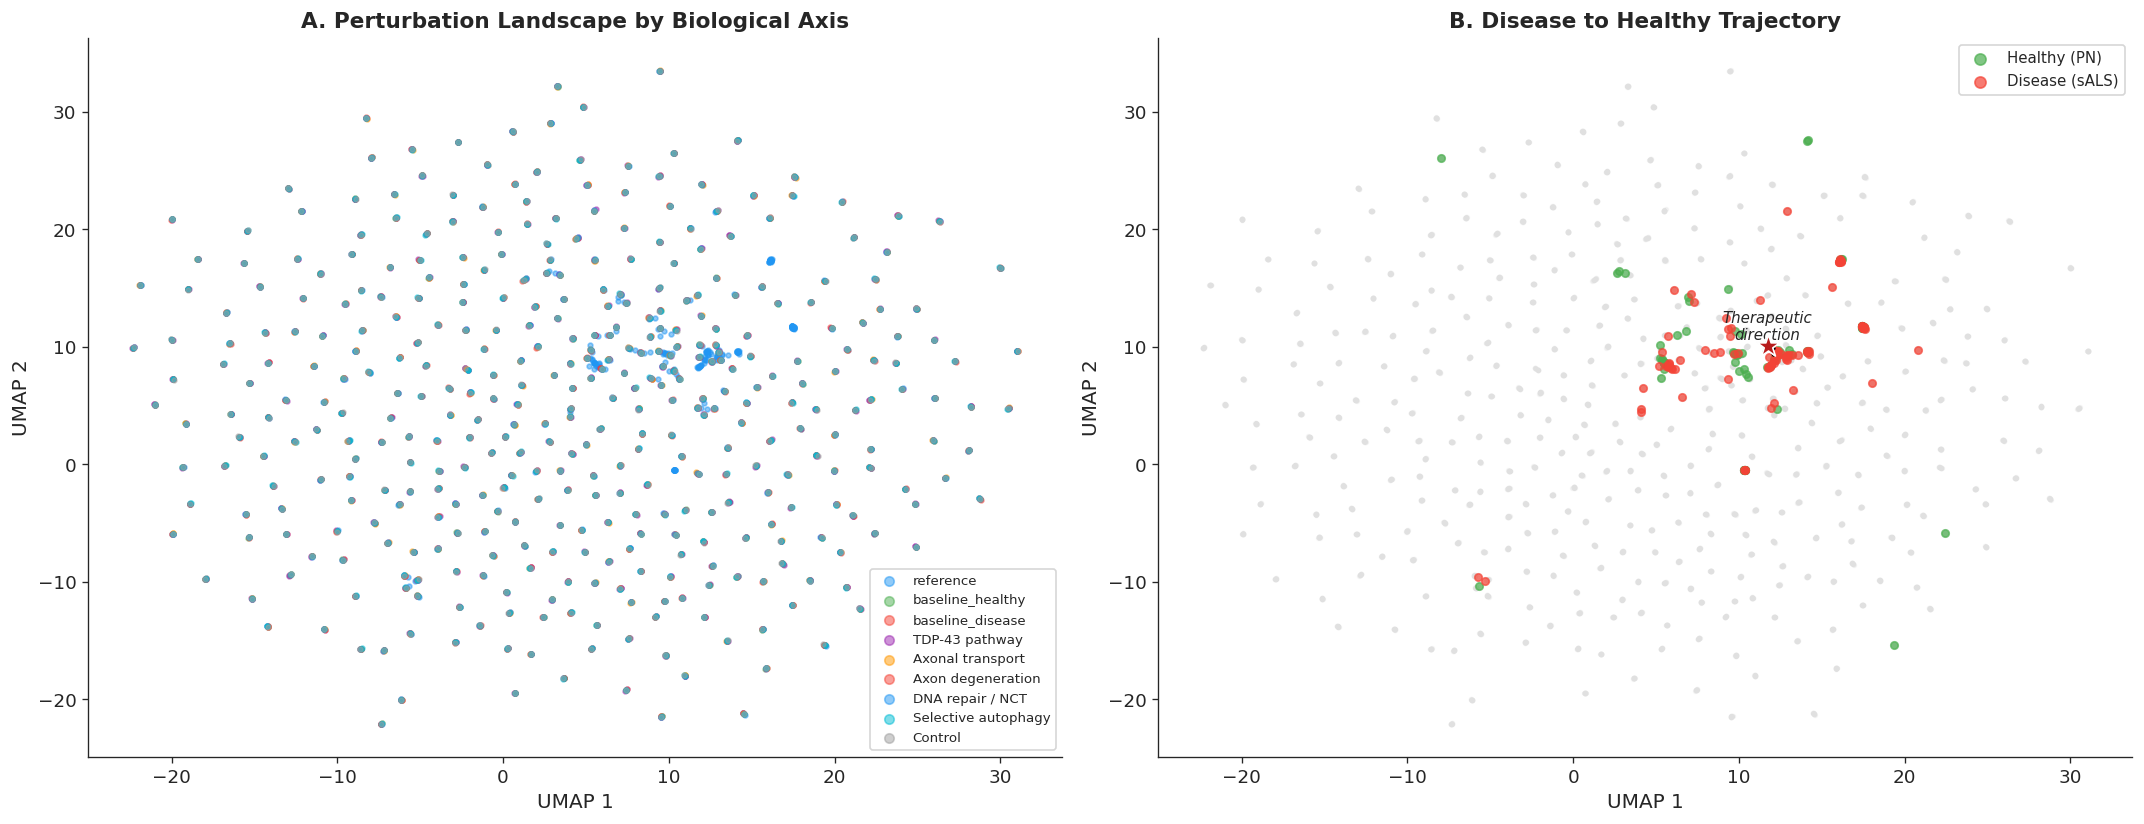

Saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/notebook03_umap_overview.png


In [4]:
print("Computing UMAP (cosine distance)...")
reducer = umap.UMAP(
    n_components=2, metric='cosine', n_neighbors=30,
    min_dist=0.3, spread=1.0, random_state=RANDOM_STATE,
)
X_umap = reducer.fit_transform(X_joint)
print(f"UMAP complete: {X_umap.shape}")

# ── FIGURE: OVERVIEW ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel A: By biological axis
ax = axes[0]
category_palette = {
    'reference':         '#2196F3',
    'baseline_healthy':  '#4CAF50',
    'baseline_disease':  '#F44336',
    'TDP-43 pathway':    '#9C27B0',
    'Axonal transport':  '#FF9800',
    'Axon degeneration': '#F44336',
    'DNA repair / NCT':  '#2196F3',
    'Selective autophagy': '#00BCD4',
    'Control':           '#9E9E9E',
    'unknown':           '#BDBDBD',
}
for cat, color in category_palette.items():
    mask = categories == cat
    if mask.any():
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1], c=color, s=8, alpha=0.5, label=cat)
ax.set_title('A. Perturbation Landscape by Biological Axis', fontweight='bold')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=8, markerscale=2, frameon=True, loc='best')
sns.despine(ax=ax)

# Panel B: Disease-to-healthy trajectory
ax = axes[1]
ax.scatter(X_umap[:, 0], X_umap[:, 1], c='#E0E0E0', s=5, alpha=0.3, rasterized=True)
healthy_mask = labels == 'Healthy (PN)'
disease_mask = labels == 'Disease (sALS)'
ax.scatter(X_umap[healthy_mask, 0], X_umap[healthy_mask, 1], c='#4CAF50', s=20, alpha=0.7, label='Healthy (PN)', zorder=3)
ax.scatter(X_umap[disease_mask, 0], X_umap[disease_mask, 1], c='#F44336', s=20, alpha=0.7, label='Disease (sALS)', zorder=3)

h_umap = X_umap[healthy_mask].mean(axis=0)
d_umap = X_umap[disease_mask].mean(axis=0)
ax.scatter(*h_umap, c='#1B5E20', s=200, marker='*', zorder=5, edgecolors='white', linewidth=1)
ax.scatter(*d_umap, c='#B71C1C', s=200, marker='*', zorder=5, edgecolors='white', linewidth=1)
ax.annotate('', xy=h_umap, xytext=d_umap, arrowprops=dict(arrowstyle='->', color='black', lw=2, ls='--'))
mid = (h_umap + d_umap) / 2
ax.text(mid[0], mid[1] + 0.5, 'Therapeutic\ndirection', ha='center', fontsize=9, style='italic')
ax.set_title('B. Disease to Healthy Trajectory', fontweight='bold')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=9, markerscale=1.5, frameon=True, loc='best')
sns.despine(ax=ax)

plt.tight_layout()
fig_path = FIGURES_DIR / 'notebook03_umap_overview.png'
plt.savefig(str(fig_path), dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

### 4.1 Per-Gene Perturbation Trajectories

Each panel highlights a single gene's perturbation effect, showing how perturbed cells (coloured) redistribute relative to the baseline disease population (grey). Genes that shift cells toward the healthy cluster are therapeutic candidates.

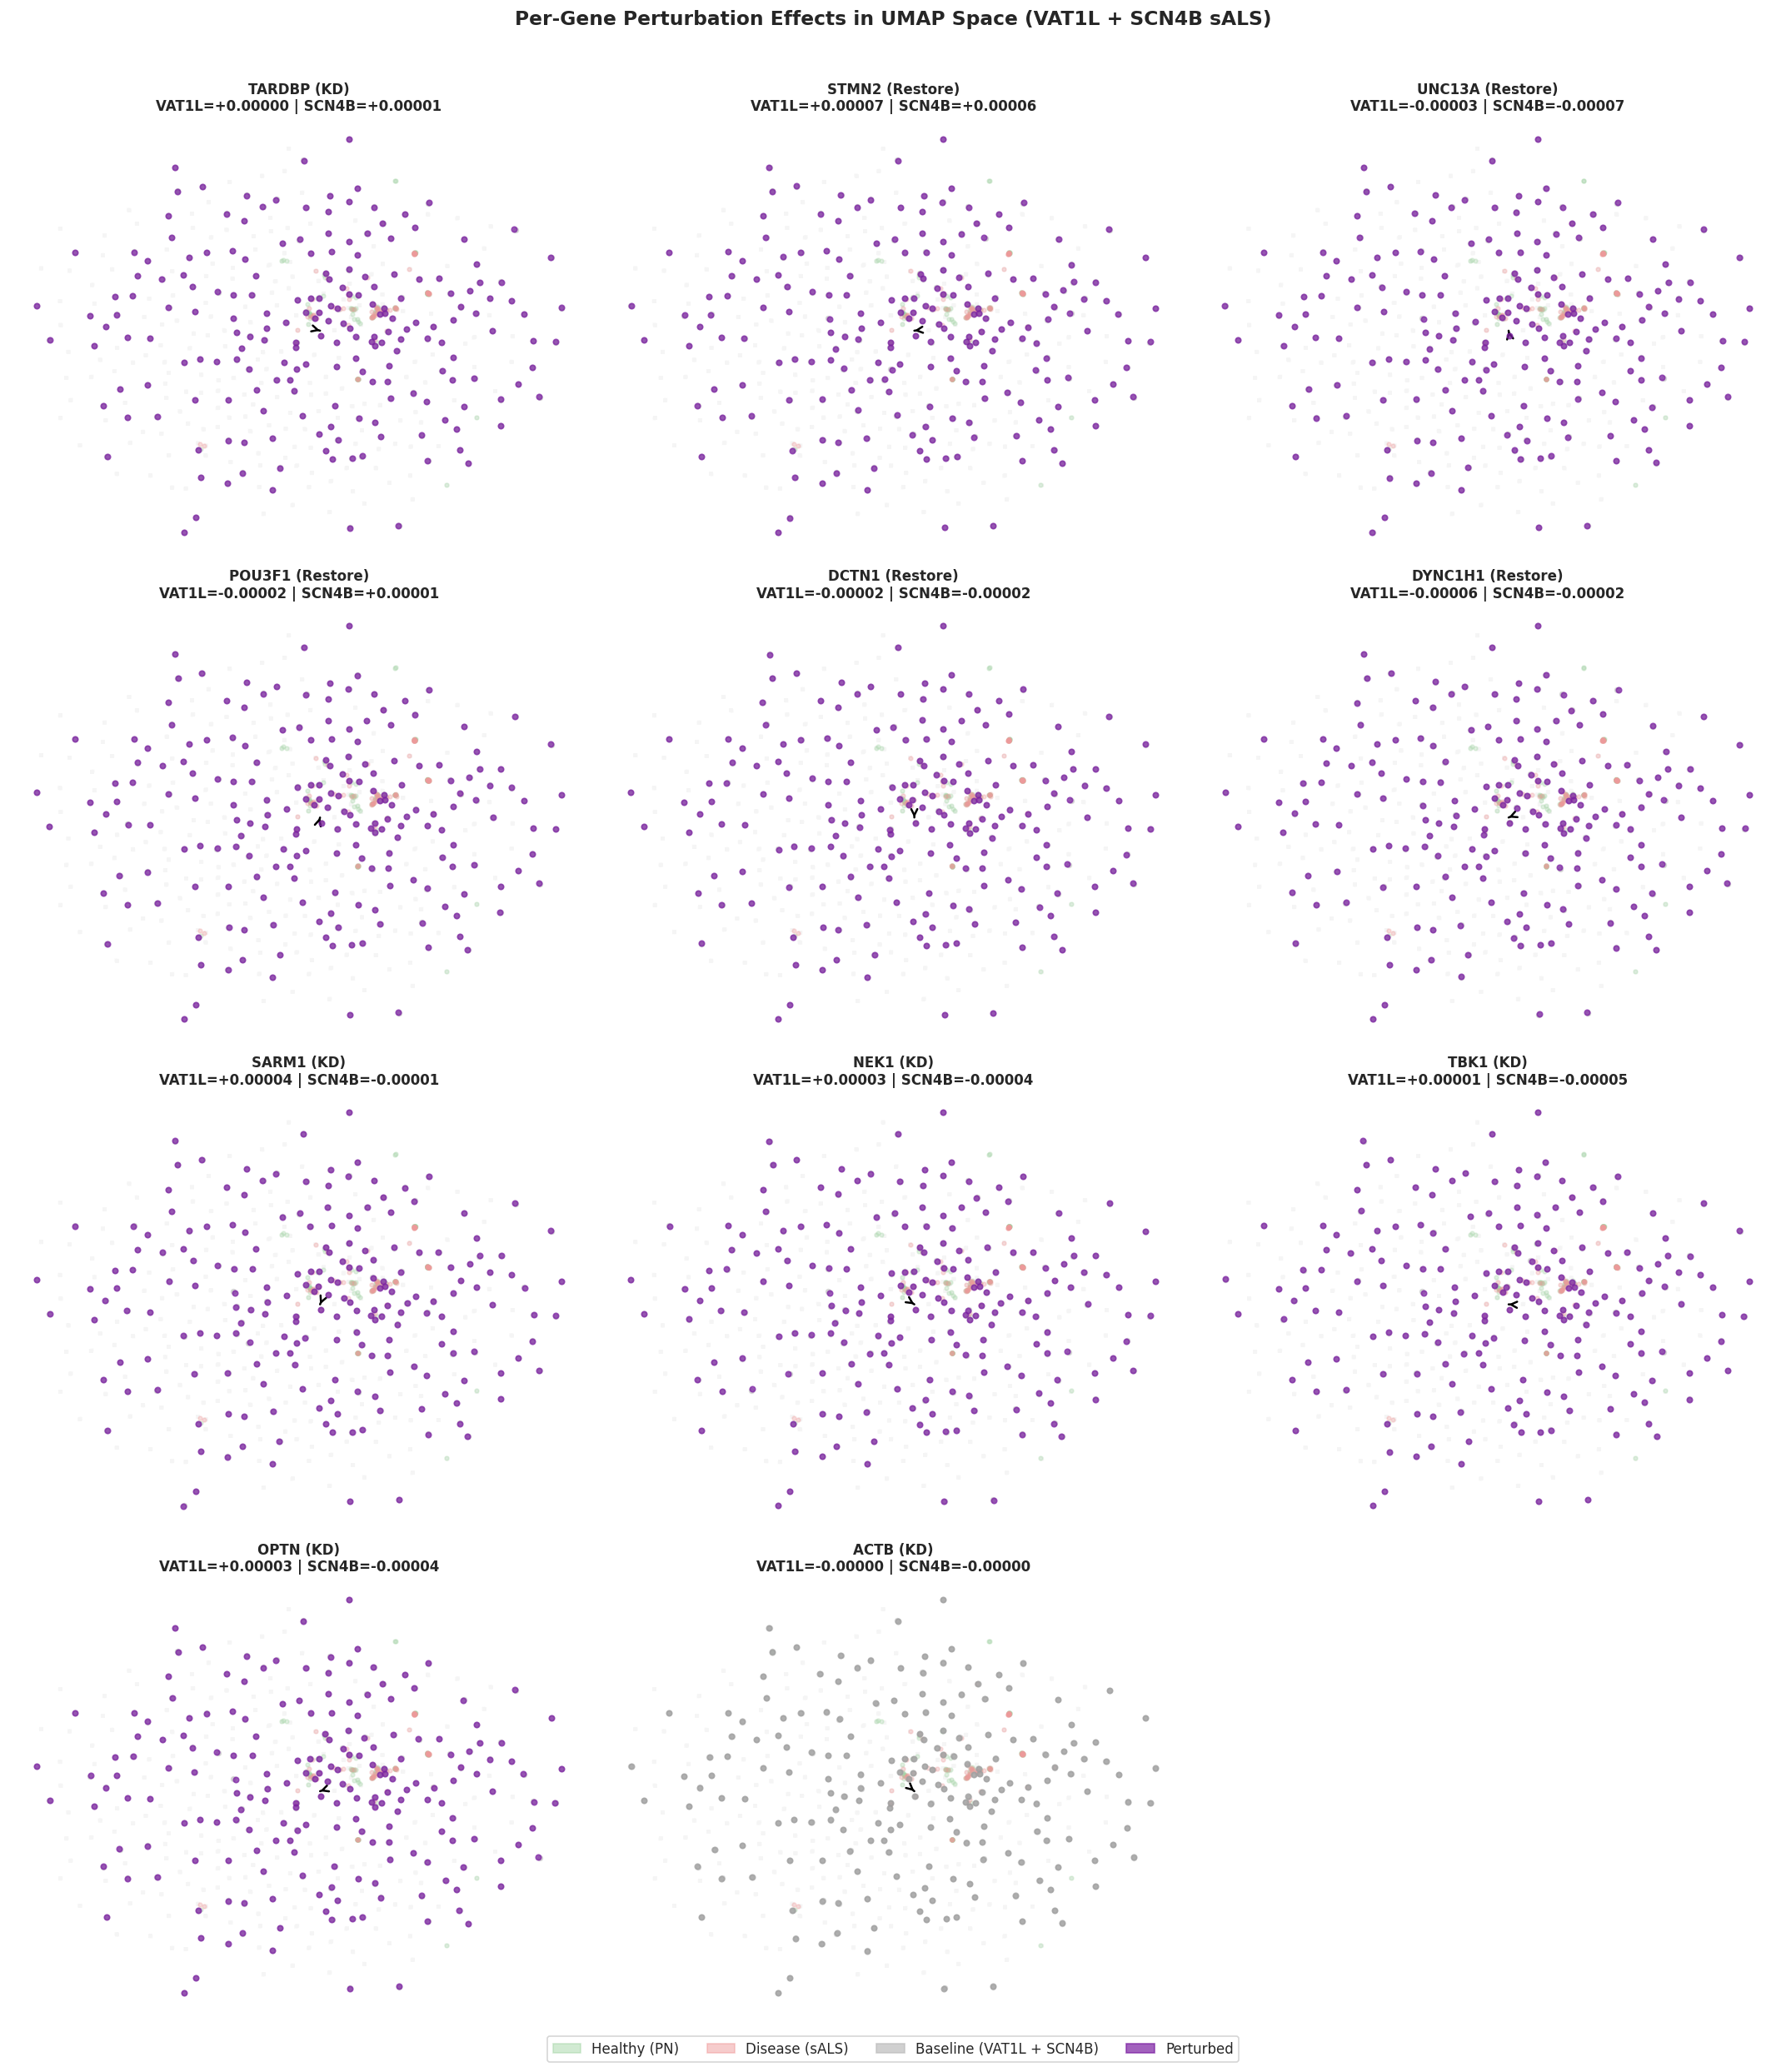

Saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/notebook03_umap_per_gene.png


In [5]:
perturbation_genes = [g for g in available_genes if g != 'ACTB']
gene_list = perturbation_genes + ['ACTB']
ncols = 3
nrows = int(np.ceil(len(gene_list) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes_flat = axes.flatten()

# Include both sALS baselines for background context
baseline_disease_mask = np.array([('Baseline' in l and 'sALS' in l) for l in labels])

for idx, gene in enumerate(gene_list):
    ax = axes_flat[idx]
    ax.scatter(X_umap[:, 0], X_umap[:, 1], c='#F5F5F5', s=3, alpha=0.2, rasterized=True)
    ax.scatter(X_umap[healthy_mask, 0], X_umap[healthy_mask, 1], c='#A5D6A7', s=8, alpha=0.3)
    ax.scatter(X_umap[disease_mask, 0], X_umap[disease_mask, 1], c='#EF9A9A', s=8, alpha=0.3)
    ax.scatter(X_umap[baseline_disease_mask, 0], X_umap[baseline_disease_mask, 1],
               c='#BDBDBD', s=12, alpha=0.5, label='Baseline')
    
    # Filter to disease cell perturbations only (both VAT1L and SCN4B)
    gene_mask_arr = (genes == gene) & np.array([c == 'disease_pert' for c in conditions])
    if gene_mask_arr.any():
        color = '#9E9E9E' if gene == 'ACTB' else '#7B1FA2'
        ax.scatter(X_umap[gene_mask_arr, 0], X_umap[gene_mask_arr, 1],
                   c=color, s=15, alpha=0.7, zorder=4)
        pert_c = X_umap[gene_mask_arr].mean(axis=0)
        base_c = X_umap[baseline_disease_mask].mean(axis=0)
        ax.annotate('', xy=pert_c, xytext=base_c,
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    # Show cosine shifts for both populations
    gene_result_v = df_results[(df_results['gene'] == gene) & (df_results['population'] == 'VAT1L_sALS')]
    gene_result_s = df_results[(df_results['gene'] == gene) & (df_results['population'] == 'SCN4B_sALS')]
    d = ALS_GENE_PANEL[gene]['direction']
    dl = d.replace('knockdown','KD').replace('knockup_restore','Restore')
    if len(gene_result_v) > 0 and len(gene_result_s) > 0:
        sv = gene_result_v['mean_cosine_shift'].values[0]
        ss = gene_result_s['mean_cosine_shift'].values[0]
        ax.set_title(f"{gene} ({dl})\nVAT1L={sv:+.5f} | SCN4B={ss:+.5f}", fontweight='bold', fontsize=10)
    elif len(gene_result_v) > 0:
        shift = gene_result_v['mean_cosine_shift'].values[0]
        pval = gene_result_v['p_value_fdr'].values[0]
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        ax.set_title(f"{gene} ({dl})\ncos={shift:+.5f} {sig}", fontweight='bold', fontsize=11)
    else:
        ax.set_title(gene, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

for idx in range(len(gene_list), len(axes_flat)):
    axes_flat[idx].set_visible(False)

legend_el = [
    mpatches.Patch(color='#A5D6A7', alpha=0.5, label='Healthy (PN)'),
    mpatches.Patch(color='#EF9A9A', alpha=0.5, label='Disease (sALS)'),
    mpatches.Patch(color='#BDBDBD', alpha=0.7, label='Baseline (VAT1L + SCN4B)'),
    mpatches.Patch(color='#7B1FA2', alpha=0.7, label='Perturbed'),
]
fig.legend(handles=legend_el, loc='lower center', ncol=4, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Per-Gene Perturbation Effects in UMAP Space (VAT1L + SCN4B sALS)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = FIGURES_DIR / 'notebook03_umap_per_gene.png'
plt.savefig(str(fig_path), dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


## 5. PCA: Disease-to-Healthy Axis Decomposition

While UMAP captures local structure, PCA provides a linear, interpretable decomposition. We define **PC1** as the disease-to-healthy axis and project perturbations onto it, decomposing shifts into **on-axis** (therapeutic) and **off-axis** (potentially off-target) components.

In [6]:
# Fit PCA on POPULATION-SPECIFIC baselines (primary_pop vs its PN counterpart).
# Using global emb_healthy/disease_global causes all perturbation embeddings to
# project far off the reference axis (different population distributions).
# Population-specific PCA centres the disease-healthy axis correctly.
paired_pop = primary_pop.replace('sALS', 'PN')
X_reference = np.vstack([baseline_embeddings[primary_pop], baseline_embeddings[paired_pop]])
pca = PCA(n_components=20, random_state=RANDOM_STATE)
pca.fit(X_reference)

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

X_pca = pca.transform(X_joint)

# Ensure positive PC1 = toward healthy
pop_pn_mask   = np.array([f'Baseline {paired_pop}' in l for l in labels])
pop_als_mask  = np.array([f'Baseline {primary_pop}' in l for l in labels])
if X_pca[pop_pn_mask, 0].mean() < X_pca[pop_als_mask, 0].mean():
    X_pca[:, 0] *= -1
    pca.components_[0] *= -1
    print('(Flipped PC1 so positive = toward healthy)')

print(f"Population PC1 — Healthy ({paired_pop}): {X_pca[pop_pn_mask, 0].mean():+.4f}")
print(f"Population PC1 — Disease ({primary_pop}): {X_pca[pop_als_mask, 0].mean():+.4f}")

# ── PER-GENE TRAJECTORY DECOMPOSITION — BOTH POPULATIONS ────────────────────
projection_results = []

# VAT1L: use the primary PCA fitted above
pc_primary_baseline = pca.transform(baseline_embeddings[primary_pop]).mean(axis=0)

for gene in available_genes:
    key = (gene, primary_pop)
    if key not in embeddings_store:
        continue
    pc_pert = pca.transform(embeddings_store[key])
    delta_pc = pc_pert.mean(axis=0) - pc_primary_baseline
    
    on_axis = delta_pc[0]
    off_axis_mag = np.sqrt(np.sum(delta_pc[1:]**2))
    shift_mag = np.sqrt(np.sum(delta_pc[:5]**2))
    if shift_mag > 0:
        angle_deg = np.degrees(np.arccos(np.clip(on_axis / shift_mag, -1, 1)))
    else:
        angle_deg = 90.0
    
    projection_results.append({
        'gene': gene, 'population': 'VAT1L_sALS', 'on_axis_shift': on_axis,
        'off_axis_magnitude': off_axis_mag, 'total_shift': shift_mag,
        'angle_to_therapeutic_axis': angle_deg,
        'specificity': on_axis / (abs(on_axis) + off_axis_mag) if (abs(on_axis) + off_axis_mag) > 0 else 0,
    })

# SCN4B: fit a separate PCA on SCN4B population pair
scn4b_pop = 'SCN4B_sALS'
scn4b_paired = 'SCN4B_PN'
if scn4b_pop in baseline_embeddings and scn4b_paired in baseline_embeddings:
    X_ref_scn4b = np.vstack([baseline_embeddings[scn4b_pop], baseline_embeddings[scn4b_paired]])
    pca_scn4b = PCA(n_components=20, random_state=RANDOM_STATE)
    pca_scn4b.fit(X_ref_scn4b)
    
    # Orient PC1: positive = toward healthy
    scn4b_pn_proj = pca_scn4b.transform(baseline_embeddings[scn4b_paired]).mean(axis=0)
    scn4b_als_proj = pca_scn4b.transform(baseline_embeddings[scn4b_pop]).mean(axis=0)
    if scn4b_pn_proj[0] < scn4b_als_proj[0]:
        pca_scn4b.components_[0] *= -1
    
    pc_scn4b_baseline = pca_scn4b.transform(baseline_embeddings[scn4b_pop]).mean(axis=0)
    
    print(f"\nSCN4B PCA: PC1={pca_scn4b.explained_variance_ratio_[0]*100:.1f}%, "
          f"PC2={pca_scn4b.explained_variance_ratio_[1]*100:.1f}%")
    
    for gene in available_genes:
        key = (gene, scn4b_pop)
        if key not in embeddings_store:
            continue
        pc_pert = pca_scn4b.transform(embeddings_store[key])
        delta_pc = pc_pert.mean(axis=0) - pc_scn4b_baseline
        
        on_axis = delta_pc[0]
        off_axis_mag = np.sqrt(np.sum(delta_pc[1:]**2))
        shift_mag = np.sqrt(np.sum(delta_pc[:5]**2))
        if shift_mag > 0:
            angle_deg = np.degrees(np.arccos(np.clip(on_axis / shift_mag, -1, 1)))
        else:
            angle_deg = 90.0
        
        projection_results.append({
            'gene': gene, 'population': 'SCN4B_sALS', 'on_axis_shift': on_axis,
            'off_axis_magnitude': off_axis_mag, 'total_shift': shift_mag,
            'angle_to_therapeutic_axis': angle_deg,
            'specificity': on_axis / (abs(on_axis) + off_axis_mag) if (abs(on_axis) + off_axis_mag) > 0 else 0,
        })

df_proj = pd.DataFrame(projection_results)
print("\n=== Trajectory Decomposition (Both Populations) ===\n")
print(df_proj.to_string(index=False, float_format='{:.5f}'.format))
proj_path = RESULTS_DIR / 'notebook03_trajectory_decomposition.csv'
df_proj.to_csv(str(proj_path), index=False)
print(f"\nSaved: {proj_path}")


Variance explained: PC1=35.4%, PC2=19.6%
(Flipped PC1 so positive = toward healthy)
Population PC1 — Healthy (VAT1L_PN): +0.3365
Population PC1 — Disease (VAT1L_sALS): -0.3365

SCN4B PCA: PC1=41.1%, PC2=18.7%

=== Trajectory Decomposition (Both Populations) ===

   gene population  on_axis_shift  off_axis_magnitude  total_shift  angle_to_therapeutic_axis  specificity
 TARDBP VAT1L_sALS        0.00044             0.00287      0.00159                   73.99062      0.13303
  STMN2 VAT1L_sALS        0.00923             0.03481      0.02633                   69.48219      0.20954
 UNC13A VAT1L_sALS        0.00133             0.01126      0.00585                   76.88407      0.10547
 POU3F1 VAT1L_sALS        0.00292             0.01115      0.00666                   63.99530      0.20765
  DCTN1 VAT1L_sALS        0.00155             0.01079      0.00607                   75.18640      0.12572
DYNC1H1 VAT1L_sALS       -0.00254             0.01516      0.00833                  107.73164  

### 5.1 PCA Trajectory Visualisation

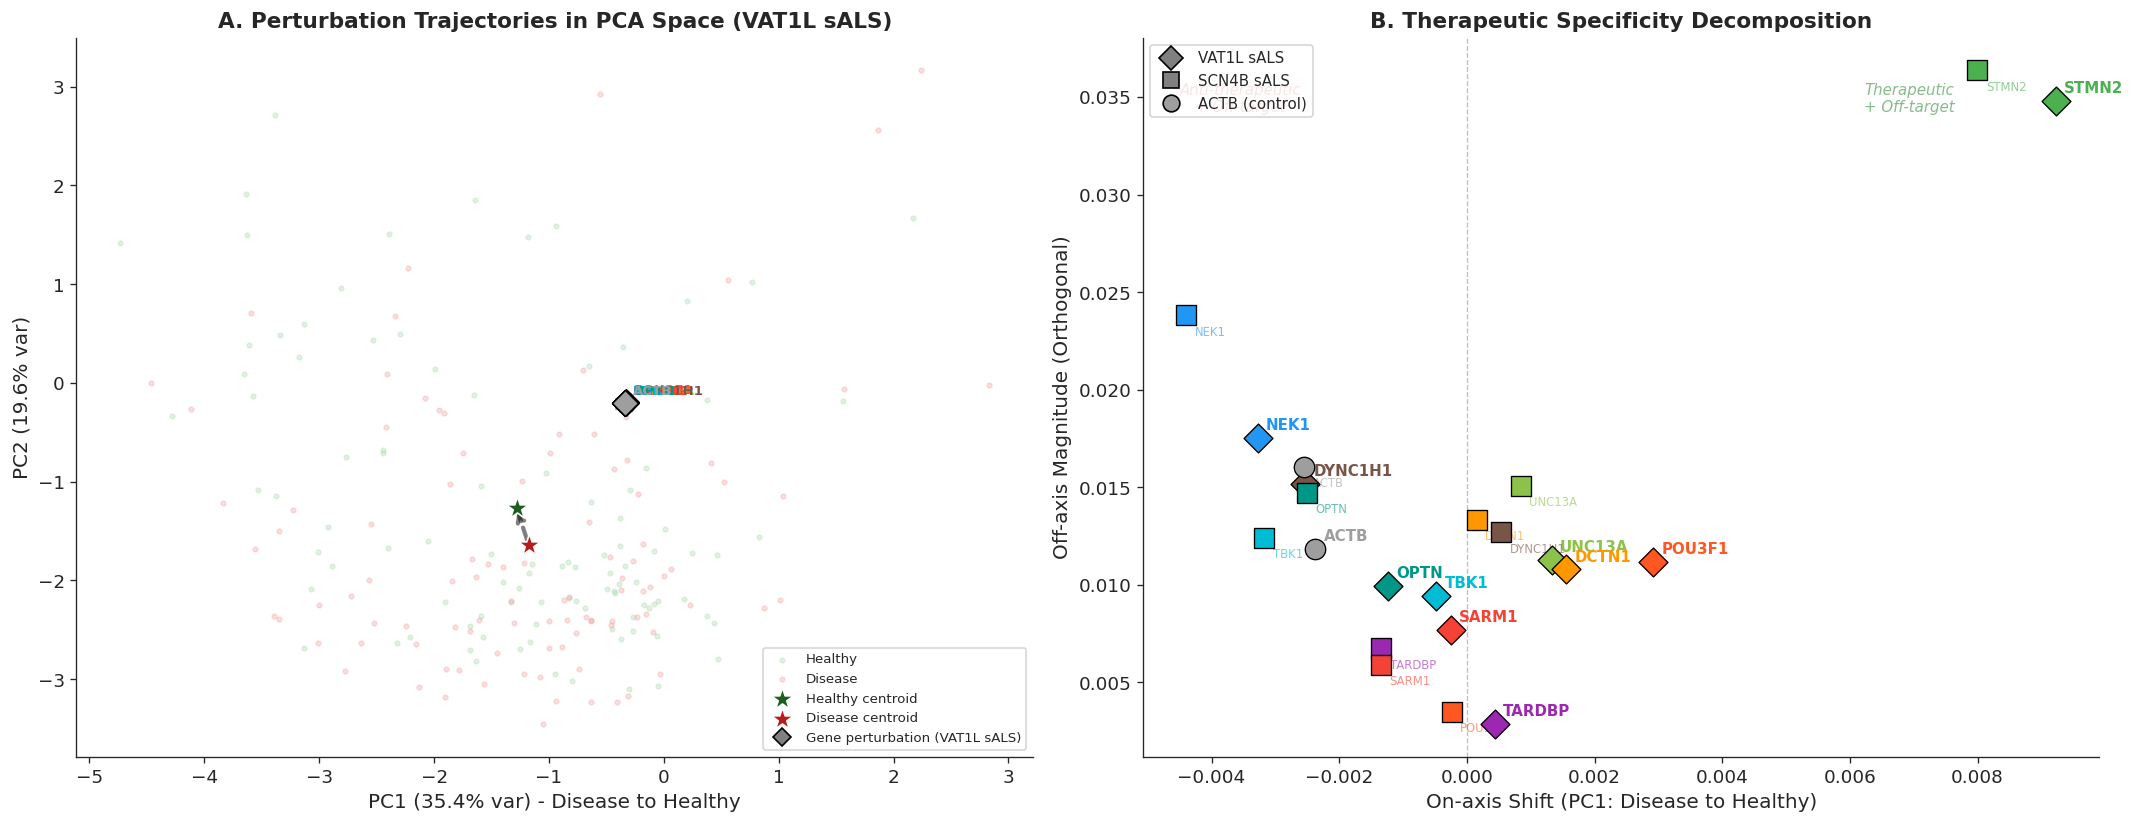

Saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/notebook03_pca_trajectories.png


In [7]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel A: PC1 vs PC2 — VAT1L perturbations projected from embeddings_store
ax = axes[0]
ax.scatter(X_pca[healthy_mask, 0], X_pca[healthy_mask, 1], c='#A5D6A7', s=8, alpha=0.3, label='Healthy', rasterized=True)
ax.scatter(X_pca[disease_mask, 0], X_pca[disease_mask, 1], c='#EF9A9A', s=8, alpha=0.3, label='Disease', rasterized=True)

h_c = X_pca[healthy_mask].mean(axis=0)
d_c = X_pca[disease_mask].mean(axis=0)
ax.scatter(h_c[0], h_c[1], c='#1B5E20', s=200, marker='*', zorder=5, edgecolors='white', linewidth=1, label='Healthy centroid')
ax.scatter(d_c[0], d_c[1], c='#B71C1C', s=200, marker='*', zorder=5, edgecolors='white', linewidth=1, label='Disease centroid')

# Project per-gene VAT1L perturbation centroids directly from embeddings_store
base_c_vat1l = pca.transform(baseline_embeddings['VAT1L_sALS']).mean(axis=0)

for gene in available_genes:
    key = (gene, 'VAT1L_sALS')
    if key not in embeddings_store:
        continue
    pc_pert = pca.transform(embeddings_store[key]).mean(axis=0)
    color = gene_colors.get(gene, '#757575')
    ax.scatter(pc_pert[0], pc_pert[1], c=color, s=120, marker='D', edgecolors='black', linewidth=0.8, zorder=6)
    ax.annotate(gene, xy=(pc_pert[0], pc_pert[1]), xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold', color=color)
    ax.annotate('', xy=pc_pert[:2], xytext=base_c_vat1l[:2],
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))

ax.annotate('', xy=h_c[:2], xytext=d_c[:2],
            arrowprops=dict(arrowstyle='->', color='black', lw=2.5, ls='--', alpha=0.5))

v1, v2 = pca.explained_variance_ratio_[0]*100, pca.explained_variance_ratio_[1]*100
ax.set_xlabel(f'PC1 ({v1:.1f}% var) - Disease to Healthy', fontsize=12)
ax.set_ylabel(f'PC2 ({v2:.1f}% var)', fontsize=12)
ax.set_title('A. Perturbation Trajectories in PCA Space (VAT1L sALS)', fontweight='bold')

# Add gene perturbation marker to legend
extra_handle = Line2D([0], [0], marker='D', color='w', markerfacecolor='grey', markersize=8,
                       markeredgecolor='black', label='Gene perturbation (VAT1L sALS)')
handles, labels_leg = ax.get_legend_handles_labels()
handles.append(extra_handle)
ax.legend(handles=handles, fontsize=8, loc='best', frameon=True)
sns.despine(ax=ax)

# Panel B: On-axis vs off-axis — both populations, distinguished by marker shape
ax = axes[1]
for _, row in df_proj.iterrows():
    gene = row['gene']
    pop = row.get('population', 'VAT1L_sALS')
    color = gene_colors.get(gene, '#757575')
    is_scn4b = 'SCN4B' in pop
    mk = 's' if is_scn4b else 'D'  # square for SCN4B, diamond for VAT1L
    if gene == 'ACTB':
        mk = 'o'
    ax.scatter(row['on_axis_shift'], row['off_axis_magnitude'],
               c=color, s=150, marker=mk, edgecolors='black', linewidth=0.8, zorder=5)
    # VAT1L gets bold labels, SCN4B gets smaller offset labels to reduce clutter
    if not is_scn4b:
        ax.annotate(gene, xy=(row['on_axis_shift'], row['off_axis_magnitude']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold', color=color)
    else:
        ax.annotate(gene, xy=(row['on_axis_shift'], row['off_axis_magnitude']),
                    xytext=(5, -12), textcoords='offset points', fontsize=7, color=color, alpha=0.6)

ax.axvline(x=0, color='grey', linestyle='--', alpha=0.5, linewidth=0.8)
xl = ax.get_xlim(); yl = ax.get_ylim()
ax.text(xl[1]*0.7, yl[1]*0.9, 'Therapeutic\n+ Off-target', ha='center', fontsize=9, style='italic', color='#388E3C', alpha=0.6)
ax.text(xl[0]*0.7 if xl[0]<0 else xl[0]+0.001, yl[1]*0.9, 'Anti-therapeutic\n+ Off-target', ha='center', fontsize=9, style='italic', color='#D32F2F', alpha=0.6)

# Legend for marker shapes
shape_legend = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor='grey', markersize=10, markeredgecolor='black', label='VAT1L sALS'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='grey', markersize=10, markeredgecolor='black', label='SCN4B sALS'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9E9E9E', markersize=10, markeredgecolor='black', label='ACTB (control)'),
]
ax.legend(handles=shape_legend, fontsize=9, frameon=True, loc='upper left')

ax.set_xlabel('On-axis Shift (PC1: Disease to Healthy)', fontsize=12)
ax.set_ylabel('Off-axis Magnitude (Orthogonal)', fontsize=12)
ax.set_title('B. Therapeutic Specificity Decomposition', fontweight='bold')
sns.despine(ax=ax)

plt.tight_layout()
fig_path = FIGURES_DIR / 'notebook03_pca_trajectories.png'
plt.savefig(str(fig_path), dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


## 6. Neighbourhood Analysis: k-NN Label Transfer

A perturbation that moves disease cells toward healthy should change the identity of their nearest neighbours. We quantify this using **k-NN label transfer**: for each perturbed cell, we find its k nearest neighbours in the reference embedding (healthy + disease) and compute the **Healthy Neighbour Fraction (HNF)**.

This approach is inspired by scIB benchmarking metrics (Luecken et al., *Nature Methods* 2022) and GeneFormer's neighbourhood-based cell classification.

In [8]:
K = 50

# Build reference index
X_ref = np.vstack([emb_healthy_global, emb_disease_global])
ref_condition = np.array(['healthy'] * len(emb_healthy_global) + ['disease'] * len(emb_disease_global))

knn = NearestNeighbors(n_neighbors=K, metric='cosine', algorithm='brute')
knn.fit(X_ref)

def compute_hnf(embeddings, knn_model, ref_labels, k=50):
    distances, indices = knn_model.kneighbors(embeddings, n_neighbors=k)
    neighbour_labels = ref_labels[indices]
    return (neighbour_labels == 'healthy').mean(axis=1)

# Compute HNF for all conditions — both disease populations
hnf_results = {}
for pop_name, emb in baseline_embeddings.items():
    if 'sALS' in pop_name:
        hnf = compute_hnf(emb, knn, ref_condition, K)
        hnf_results[f'Baseline ({pop_name})'] = hnf
        print(f"Baseline {pop_name}: HNF = {hnf.mean():.4f} +/- {hnf.std():.4f}")

for (gene, pop_name), emb in embeddings_store.items():
    if 'sALS' not in pop_name:    # disease populations only (both VAT1L and SCN4B)
        continue
    hnf = compute_hnf(emb, knn, ref_condition, K)
    direction = ALS_GENE_PANEL[gene]['direction']
    pop_short = pop_name.split('_')[0]  # 'VAT1L' or 'SCN4B'
    label = f"{gene} ({direction.replace('knockdown','KD').replace('knockup_restore','Restore')}) [{pop_short}]"
    hnf_results[label] = hnf
    print(f"{label}: HNF = {hnf.mean():.4f} +/- {hnf.std():.4f}")

# Statistical comparison against respective population baseline
# NOTE: At pretrained embedding resolution (cos_dist ~0.003), kNN neighbourhoods
# are too compact to distinguish per-gene perturbations. All dHNF values are expected
# to be near-zero (< 0.001) and non-significant. This is a resolution limitation,
# not a code error — HNF will become informative after fine-tuning.

hnf_summary = []
print(f"\n{'Condition':<45} {'Mean HNF':<12} {'dHNF':<12} {'p-value':<12} {'Sig'}")
print("-" * 95)

for label, hnf in hnf_results.items():
    if 'Baseline' in label:
        continue
    # Determine which baseline to compare against
    if 'VAT1L' in label:
        baseline_key = 'Baseline (VAT1L_sALS)'
    elif 'SCN4B' in label:
        baseline_key = 'Baseline (SCN4B_sALS)'
    else:
        baseline_key = [k for k in hnf_results if 'Baseline' in k][0]
    
    baseline_hnf = hnf_results.get(baseline_key)
    if baseline_hnf is None:
        continue
    
    delta_hnf = hnf.mean() - baseline_hnf.mean()
    u_stat, p_val = mannwhitneyu(hnf, baseline_hnf, alternative='two-sided')
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    gene_name = label.split(' (')[0]
    pop_name = 'VAT1L' if 'VAT1L' in label else 'SCN4B' if 'SCN4B' in label else 'unknown'
    print(f"{label:<45} {hnf.mean():<12.4f} {delta_hnf:<+12.4f} {p_val:<12.2e} {sig}")
    hnf_summary.append({'condition': label, 'gene': gene_name, 'population': pop_name,
                        'mean_hnf': hnf.mean(), 'std_hnf': hnf.std(),
                        'delta_hnf': delta_hnf, 'p_value': p_val})

print("\nNote: All dHNF values near zero and non-significant (expected at pretrained resolution).")
print("HNF will become informative after domain-specific fine-tuning (centroid separation ~0.1+).")

df_hnf = pd.DataFrame(hnf_summary)
hnf_path = RESULTS_DIR / 'notebook03_hnf_results.csv'
df_hnf.to_csv(str(hnf_path), index=False)
print(f"\nSaved: {hnf_path}")


Baseline VAT1L_sALS: HNF = 0.4244 +/- 0.0639
Baseline SCN4B_sALS: HNF = 0.4142 +/- 0.0710
TARDBP (KD) [VAT1L]: HNF = 0.4242 +/- 0.0642
STMN2 (Restore) [VAT1L]: HNF = 0.4250 +/- 0.0638
UNC13A (Restore) [VAT1L]: HNF = 0.4246 +/- 0.0630
POU3F1 (Restore) [VAT1L]: HNF = 0.4244 +/- 0.0638
DCTN1 (Restore) [VAT1L]: HNF = 0.4250 +/- 0.0637
DYNC1H1 (Restore) [VAT1L]: HNF = 0.4250 +/- 0.0641
SARM1 (KD) [VAT1L]: HNF = 0.4252 +/- 0.0637
NEK1 (KD) [VAT1L]: HNF = 0.4252 +/- 0.0642
TBK1 (KD) [VAT1L]: HNF = 0.4252 +/- 0.0637
OPTN (KD) [VAT1L]: HNF = 0.4244 +/- 0.0638
ACTB (KD) [VAT1L]: HNF = 0.4244 +/- 0.0639
TARDBP (KD) [SCN4B]: HNF = 0.4152 +/- 0.0711
STMN2 (Restore) [SCN4B]: HNF = 0.4150 +/- 0.0703
UNC13A (Restore) [SCN4B]: HNF = 0.4138 +/- 0.0704
POU3F1 (Restore) [SCN4B]: HNF = 0.4142 +/- 0.0704
DCTN1 (Restore) [SCN4B]: HNF = 0.4142 +/- 0.0706
DYNC1H1 (Restore) [SCN4B]: HNF = 0.4148 +/- 0.0702
SARM1 (KD) [SCN4B]: HNF = 0.4142 +/- 0.0706
NEK1 (KD) [SCN4B]: HNF = 0.4154 +/- 0.0702
TBK1 (KD) [SCN4B]: 

### 6.1 Neighbourhood Analysis Visualisation

/tmp/ipykernel_41775/3602302160.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='condition', y='HNF', order=order, palette=palette,
/tmp/ipykernel_41775/3602302160.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace(' (', '\n(') for o in order], rotation=45, ha='right', fontsize=9)


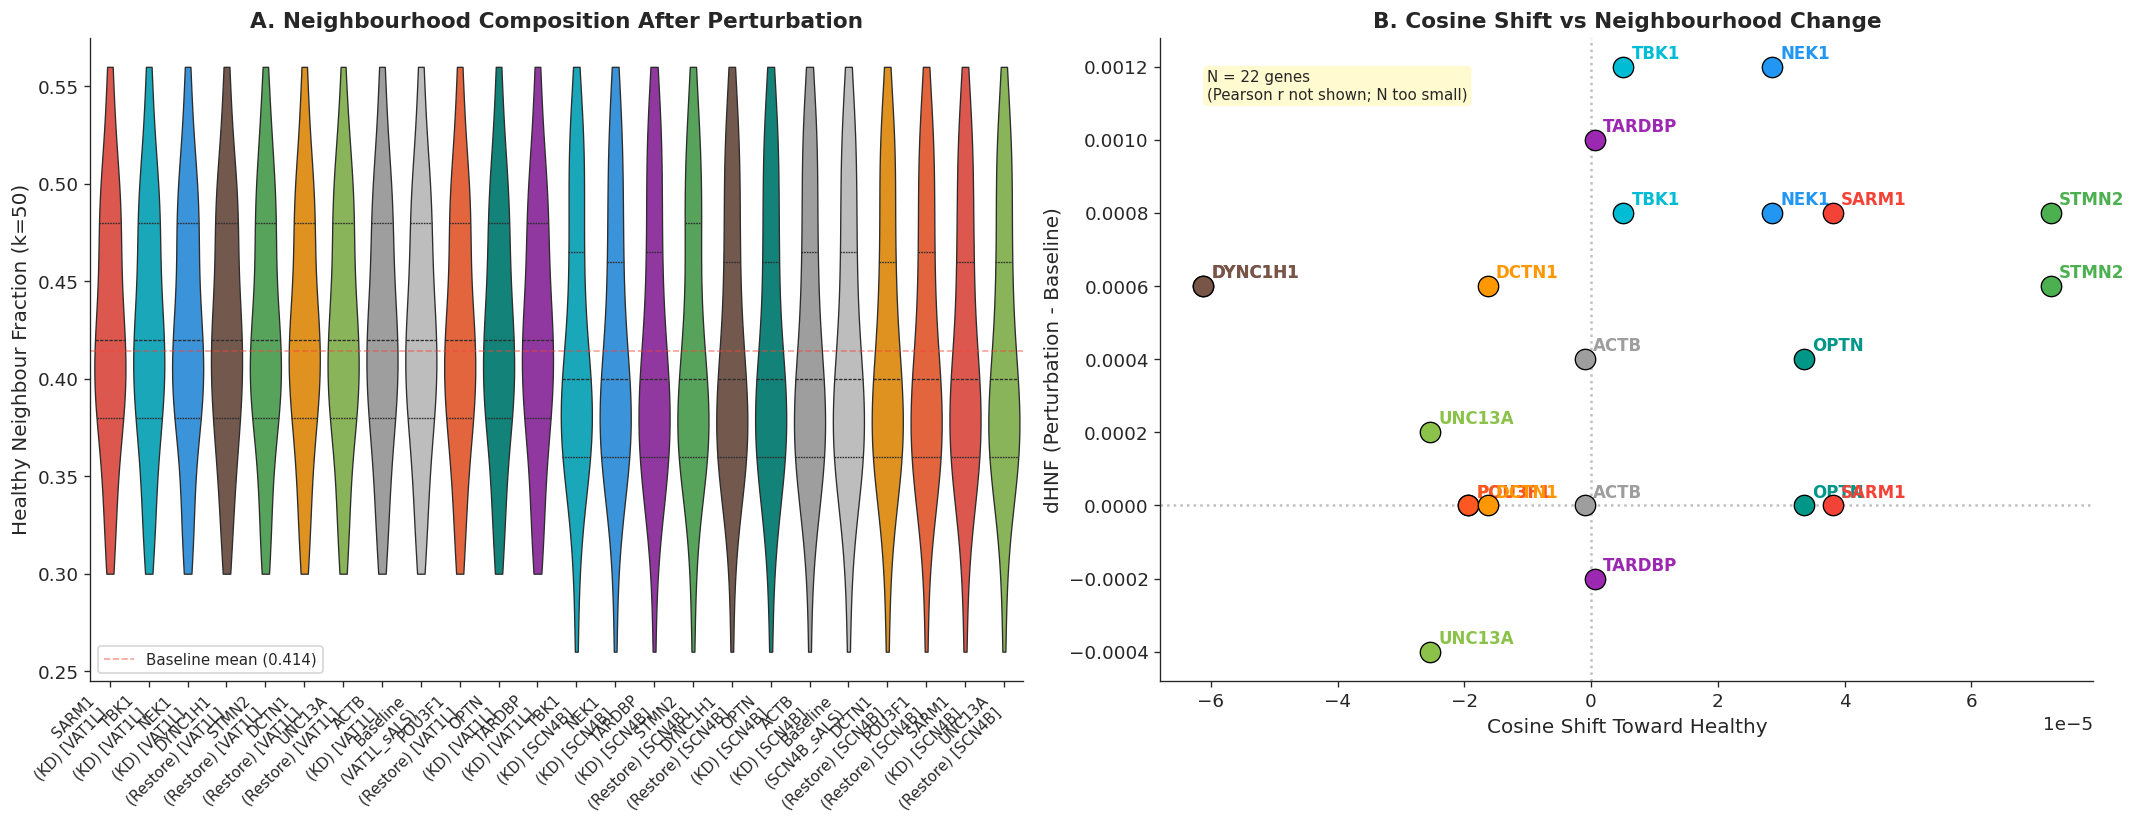

Saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/notebook03_neighbourhood_analysis.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel A: HNF violin
ax = axes[0]
plot_data = []
for label, hnf in hnf_results.items():
    for val in hnf:
        plot_data.append({'condition': label, 'HNF': val})
df_plot = pd.DataFrame(plot_data)
order = df_plot.groupby('condition')['HNF'].mean().sort_values(ascending=False).index.tolist()

palette = {}
for label in order:
    if 'Baseline' in label:
        palette[label] = '#BDBDBD'
    elif 'ACTB' in label:
        palette[label] = '#9E9E9E'
    else:
        gn = label.split(' (')[0]
        palette[label] = gene_colors.get(gn, '#757575')

sns.violinplot(data=df_plot, x='condition', y='HNF', order=order, palette=palette,
               inner='quartile', cut=0, ax=ax, linewidth=0.8)
ax.axhline(y=baseline_hnf.mean(), color='#F44336', linestyle='--', alpha=0.5,
           linewidth=1, label=f'Baseline mean ({baseline_hnf.mean():.3f})')
ax.set_xticklabels([o.replace(' (', '\n(') for o in order], rotation=45, ha='right', fontsize=9)
ax.set_ylabel(f'Healthy Neighbour Fraction (k={K})', fontsize=12)
ax.set_xlabel('')
ax.set_title('A. Neighbourhood Composition After Perturbation', fontweight='bold')
ax.legend(fontsize=9, frameon=True)
sns.despine(ax=ax)

# Panel B: dHNF vs cosine shift correlation
ax = axes[1]
cos_shifts_plot = []
hnf_deltas_plot = []
for _, row in df_hnf.iterrows():
    gene = row['gene']
    cos_row = df_results[(df_results['gene'] == gene) & (df_results['population'] == primary_pop)]
    if len(cos_row) > 0:
        color = gene_colors.get(gene, '#757575')
        cs = cos_row['mean_cosine_shift'].values[0]
        dh = row['delta_hnf']
        ax.scatter(cs, dh, c=color, s=150, edgecolors='black', linewidth=0.8, zorder=5)
        ax.annotate(gene, xy=(cs, dh), xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold', color=color)
        cos_shifts_plot.append(cs)
        hnf_deltas_plot.append(dh)

# Pearson r omitted: N=7 non-ACTB genes is too small for a meaningful correlation.
# Trend and significance cannot be reliably estimated at this sample size.
if len(cos_shifts_plot) > 2:
    ax.text(0.05, 0.95, f'N = {len(cos_shifts_plot)} genes\n(Pearson r not shown; N too small)',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF9C4', alpha=0.8))

ax.axhline(y=0, color='grey', linestyle=':', alpha=0.5)
ax.axvline(x=0, color='grey', linestyle=':', alpha=0.5)
ax.set_xlabel('Cosine Shift Toward Healthy', fontsize=12)
ax.set_ylabel('dHNF (Perturbation - Baseline)', fontsize=12)
ax.set_title('B. Cosine Shift vs Neighbourhood Change', fontweight='bold')
sns.despine(ax=ax)

plt.tight_layout()
fig_path = FIGURES_DIR / 'notebook03_neighbourhood_analysis.png'
plt.savefig(str(fig_path), dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## 7. Hierarchical Clustering of Perturbation Signatures

Genes that produce similar embedding displacement patterns may share regulatory mechanisms. We cluster genes by their **perturbation displacement vectors**, testing whether the **5 biological axes** (TDP-43, axonal transport, axon degeneration, DNA repair/NCT, selective autophagy) are recovered as distinct embedding clusters.

**Hypothesis (from notebook 02 results):**
- STMN2 and UNC13A should co-cluster — both are TDP-43 downstream cryptic exon targets with correlated expression loss
- TBK1 and OPTN should cluster together — upstream-downstream partners in the same selective autophagy pathway
- DCTN1 and DYNC1H1 should be proximal — dynactin/dynein complex components operating on the same retrograde transport machinery
- TARDBP and POU3F1 may cluster near baseline (near-zero shifts expected at pretrained resolution)
- SARM1 and NEK1 are mechanistically orthogonal to each other and to the TDP-43 axis; they may form singletons or group by shift magnitude rather than biology


Displacement matrix: (11, 512)


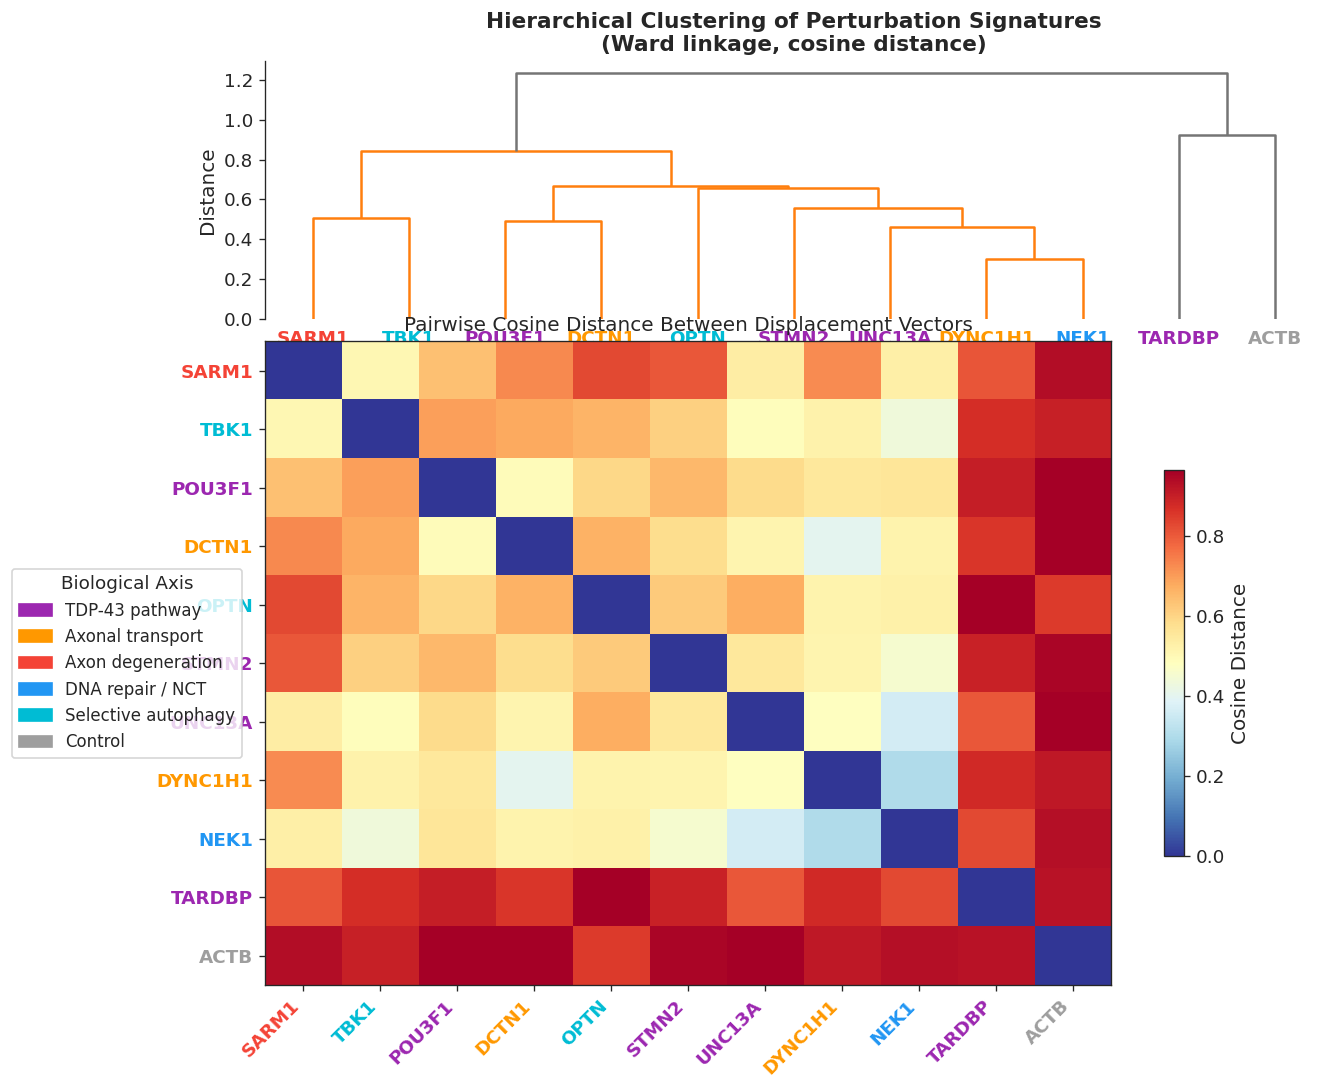

Saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/notebook03_hierarchical_clustering.png

=== Cluster Assignments (k=5) ===

  Cluster 1: ['SARM1', 'TBK1'] (axes: ['Axon degeneration', 'Selective autophagy'])
  Cluster 2: ['POU3F1', 'DCTN1'] (axes: ['TDP-43 pathway', 'Axonal transport'])
  Cluster 3: ['STMN2', 'UNC13A', 'DYNC1H1', 'NEK1', 'OPTN'] (axes: ['TDP-43 pathway', 'TDP-43 pathway', 'Axonal transport', 'DNA repair / NCT', 'Selective autophagy'])
  Cluster 4: ['TARDBP'] (axes: ['TDP-43 pathway'])
  Cluster 5: ['ACTB'] (axes: ['Control'])

=== Hypothesis Validation ===
  TDP-43 cryptic exon pair: STMN2↔UNC13A — ✓ Co-cluster | cosine dist = 0.5515
  Selective autophagy pair: TBK1↔OPTN — ✗ Split (cluster 1 vs 3) | cosine dist = 0.6624
  Dynein/dynactin transport pair: DCTN1↔DYNC1H1 — ✗ Split (cluster 2 vs 3) | cosine dist = 0.4006


In [10]:
# Compute displacement vectors: mean(perturbed) - mean(baseline)
baseline_emb = None
for pop_name, emb in baseline_embeddings.items():
    if pop_name == primary_pop:
        baseline_emb = emb
        break
if baseline_emb is None:
    baseline_emb = emb_disease_global
baseline_mean = baseline_emb.mean(axis=0)

displacement_vectors = {}
for gene in available_genes:
    key = (gene, primary_pop)
    if key in embeddings_store:
        displacement_vectors[gene] = embeddings_store[key].mean(axis=0) - baseline_mean

gene_order_clust = list(displacement_vectors.keys())
D = np.vstack([displacement_vectors[g] for g in gene_order_clust])
print(f"Displacement matrix: {D.shape}")

cos_dist = pdist(D, metric='cosine')
cos_dist_sq = squareform(cos_dist)
linkage_matrix = linkage(cos_dist, method='ward')

# ── DENDROGRAM + HEATMAP ────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 2.5], width_ratios=[0.8, 4], hspace=0.05, wspace=0.05)

ax_dendro = fig.add_subplot(gs[0, 1])
dend = dendrogram(linkage_matrix, labels=gene_order_clust, ax=ax_dendro,
                  leaf_rotation=0, leaf_font_size=11,
                  above_threshold_color='#757575',
                  color_threshold=0.7 * max(linkage_matrix[:, 2]))
for lbl in ax_dendro.get_xticklabels():
    gene = lbl.get_text()
    axis_name = ALS_GENE_PANEL.get(gene, {}).get('axis', 'unknown')
    lbl.set_color(axis_colors.get(axis_name, '#757575'))
    lbl.set_fontweight('bold')
ax_dendro.set_title('Hierarchical Clustering of Perturbation Signatures\n(Ward linkage, cosine distance)',
                    fontweight='bold', fontsize=13)
ax_dendro.set_ylabel('Distance')
sns.despine(ax=ax_dendro, bottom=True)

ax_hm = fig.add_subplot(gs[1, 1])
d_order = dend['leaves']
genes_ord = [gene_order_clust[i] for i in d_order]
D_ord = cos_dist_sq[np.ix_(d_order, d_order)]
im = ax_hm.imshow(D_ord, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=np.percentile(cos_dist_sq, 95))
ax_hm.set_xticks(range(len(genes_ord)))
ax_hm.set_xticklabels(genes_ord, fontsize=11, fontweight='bold', rotation=45, ha='right')
ax_hm.set_yticks(range(len(genes_ord)))
ax_hm.set_yticklabels(genes_ord, fontsize=11, fontweight='bold')
for tick_labels in [ax_hm.get_xticklabels(), ax_hm.get_yticklabels()]:
    for lbl in tick_labels:
        gene = lbl.get_text()
        ax_nm = ALS_GENE_PANEL.get(gene, {}).get('axis', 'unknown')
        lbl.set_color(axis_colors.get(ax_nm, '#757575'))
plt.colorbar(im, ax=ax_hm, label='Cosine Distance', shrink=0.6)
ax_hm.set_title('Pairwise Cosine Distance Between Displacement Vectors', fontsize=12)

ax_leg = fig.add_subplot(gs[1, 0])
ax_leg.axis('off')
leg_el = [mpatches.Patch(color=c, label=a) for a, c in axis_colors.items()]
ax_leg.legend(handles=leg_el, loc='center', fontsize=10, title='Biological Axis',
              title_fontsize=11, frameon=True, fancybox=True)

fig_path = FIGURES_DIR / 'notebook03_hierarchical_clustering.png'
plt.savefig(str(fig_path), dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

# Cluster assignments
n_clusters = 5  # One per mechanistic axis (TDP-43, transport, degeneration, NCT, autophagy)
cluster_ids = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
print(f"\n=== Cluster Assignments (k={n_clusters}) ===\n")
for i in range(1, n_clusters + 1):
    cg = [gene_order_clust[j] for j in range(len(gene_order_clust)) if cluster_ids[j] == i]
    ca = [ALS_GENE_PANEL.get(g, {}).get('axis', '?') for g in cg]
    print(f"  Cluster {i}: {cg} (axes: {ca})")

# Hypothesis validation: check whether axis partners co-cluster
print("\n=== Hypothesis Validation ===")
expected_pairs = [
    ('STMN2', 'UNC13A', 'TDP-43 cryptic exon pair'),
    ('TBK1', 'OPTN', 'Selective autophagy pair'),
    ('DCTN1', 'DYNC1H1', 'Dynein/dynactin transport pair'),
]
for g1, g2, label in expected_pairs:
    if g1 in gene_order_clust and g2 in gene_order_clust:
        i1 = gene_order_clust.index(g1)
        i2 = gene_order_clust.index(g2)
        c1 = cluster_ids[i1]
        c2 = cluster_ids[i2]
        co_cluster = "✓ Co-cluster" if c1 == c2 else f"✗ Split (cluster {c1} vs {c2})"
        cos_d = cos_dist_sq[i1, i2]
        print(f"  {label}: {g1}↔{g2} — {co_cluster} | cosine dist = {cos_d:.4f}")

## 8. Embedding Shift Heatmap: Top Principal Components

To understand which latent dimensions are most affected by each perturbation, we visualise the mean displacement projected onto the top PCs. This reveals whether perturbations affect shared or distinct latent dimensions.

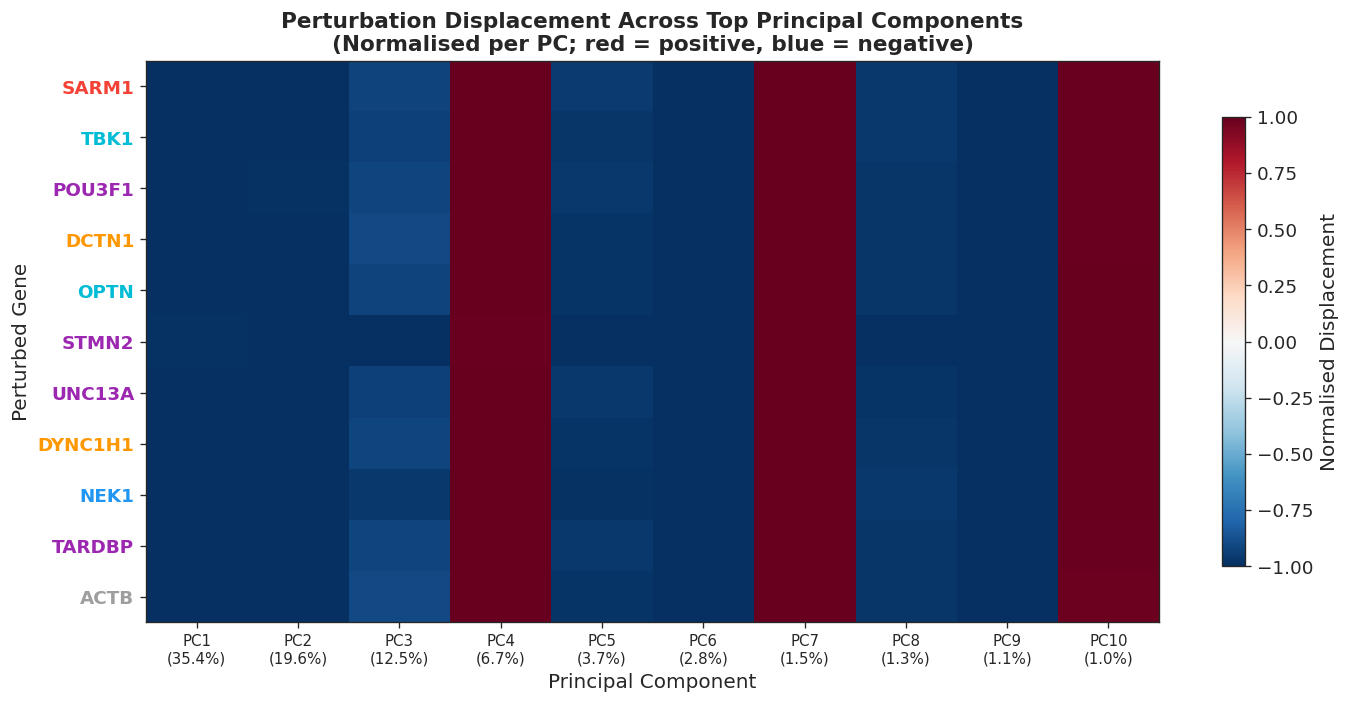

Saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/notebook03_displacement_heatmap.png


In [11]:
N_PCS = 10
D_pc = np.vstack([
    pca.transform(displacement_vectors[g].reshape(1, -1)).flatten()[:N_PCS]
    for g in gene_order_clust
])
D_pc_ordered = D_pc[d_order]

fig, ax = plt.subplots(figsize=(12, 6))
D_norm = D_pc_ordered.copy()
for j in range(D_norm.shape[1]):
    col_max = np.abs(D_norm[:, j]).max()
    if col_max > 0:
        D_norm[:, j] /= col_max

im = ax.imshow(D_norm, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_yticks(range(len(genes_ord)))
ax.set_yticklabels(genes_ord, fontsize=11, fontweight='bold')
ax.set_xticks(range(N_PCS))
ax.set_xticklabels([f'PC{i+1}\n({pca.explained_variance_ratio_[i]*100:.1f}%)' for i in range(N_PCS)], fontsize=9)
for lbl in ax.get_yticklabels():
    gene = lbl.get_text()
    ax_nm = ALS_GENE_PANEL.get(gene, {}).get('axis', 'unknown')
    lbl.set_color(axis_colors.get(ax_nm, '#757575'))
plt.colorbar(im, ax=ax, label='Normalised Displacement', shrink=0.8)
ax.set_title('Perturbation Displacement Across Top Principal Components\n'
             '(Normalised per PC; red = positive, blue = negative)', fontweight='bold', fontsize=13)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Perturbed Gene')
plt.tight_layout()
fig_path = FIGURES_DIR / 'notebook03_displacement_heatmap.png'
plt.savefig(str(fig_path), dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## 8.5 Bidirectional Consistency Analysis

A critical validation of perturbation effects is **bidirectional consistency**: if knocking down gene X in disease cells shifts them toward healthy, does knocking down gene X in healthy cells shift them *away* from healthy (toward disease)?

This analysis compares embedding shifts in disease vs healthy cells for each gene. Genes showing consistent opposing effects across conditions provide stronger evidence for causal involvement in the disease-healthy transition.


shift_distributions keys (sample): [('TARDBP', 'VAT1L_sALS'), ('STMN2', 'VAT1L_sALS'), ('UNC13A', 'VAT1L_sALS'), ('POU3F1', 'VAT1L_sALS')]
baseline_embeddings keys: ['VAT1L_sALS', 'VAT1L_PN', 'SCN4B_sALS', 'SCN4B_PN']
=== Bidirectional Consistency ===

Gene         Axis               Disease→Healthy    Healthy→Disease    Consistent?
─────────────────────────────────────────────────────────────────────────────────────
TARDBP       TDP-43 pathway     +0.000001          -0.000016          ✓ Consistent
STMN2        TDP-43 pathway     +0.000073          -0.000144          ✓ Consistent
UNC13A       TDP-43 pathway     -0.000025          -0.000040          ✗ Inconsistent
POU3F1       TDP-43 pathway     -0.000019          -0.000079          ✗ Inconsistent
DCTN1        Axonal transport   -0.000016          -0.000060          ✗ Inconsistent
DYNC1H1      Axonal transport   -0.000061          -0.000106          ✗ Inconsistent
SARM1        Axon degeneration  +0.000038          -0.000053          ✓ C

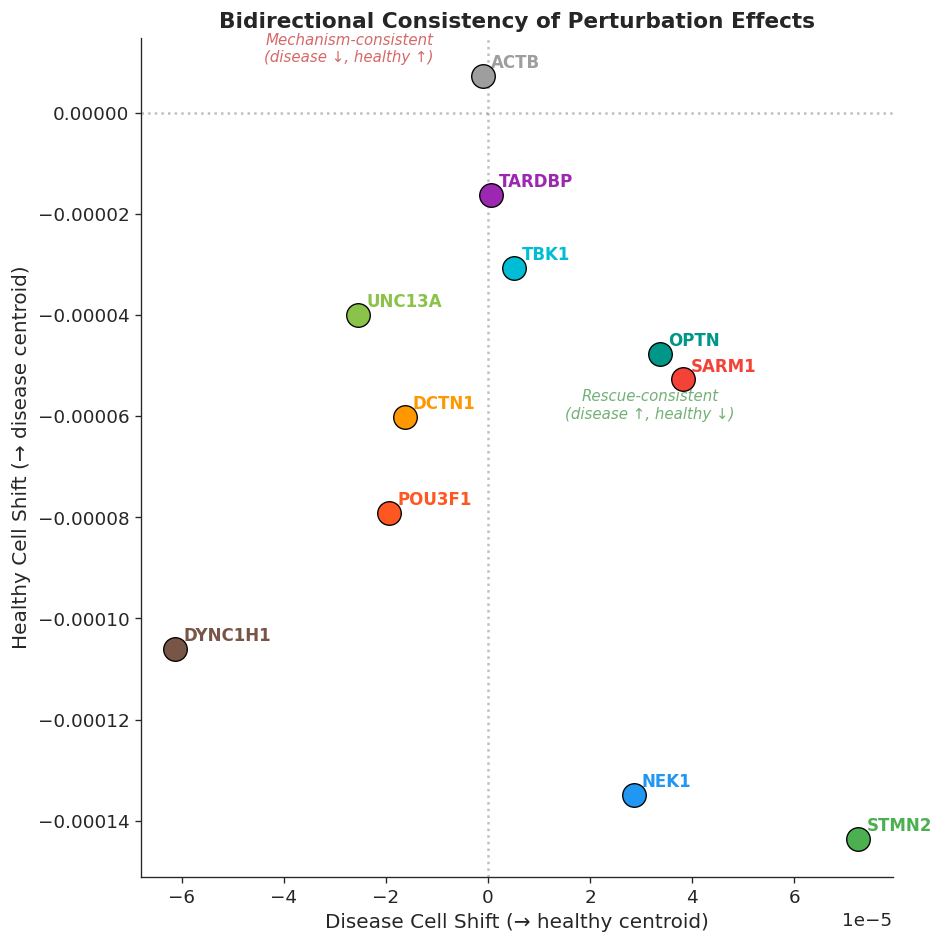


Saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/notebook03_bidirectional_consistency.png


In [12]:
# ══ BIDIRECTIONAL CONSISTENCY ANALYSIS ══════════════════════════════════════════

# Collect paired disease/healthy shifts for each gene
bidir_results = []

# Debug: verify key structure matches shift_distributions
if len(bidir_results) == 0:  # Only print on first pass
    print("shift_distributions keys (sample):", list(shift_distributions.keys())[:4])
    print("baseline_embeddings keys:", list(baseline_embeddings.keys()))

for gene in available_genes:
    # Disease cell perturbation (shift toward healthy centroid)
    disease_keys = [(gene, p) for p in baseline_embeddings if 'sALS' in p]
    healthy_keys = [(gene, p) for p in baseline_embeddings if 'PN' in p]
    
    d_shift = None
    h_shift = None
    
    for dk in disease_keys:
        if dk in shift_distributions:
            d_shift = shift_distributions[dk].mean()
            break
    
    for hk in healthy_keys:
        if hk in shift_distributions:
            h_shift = shift_distributions[hk].mean()
            break
    
    if d_shift is not None and h_shift is not None:
        if np.isnan(d_shift) or np.isnan(h_shift):
            print(f"WARNING: NaN shift value for {gene} — check shift_distributions keys")
        # For disease cells, positive shift = toward healthy (therapeutic)
        # For healthy cells, we measured shift toward disease centroid,
        # so positive = toward disease (the gene contributes to disease when active)
        bidir_results.append({
            'gene': gene,
            'axis': ALS_GENE_PANEL[gene]['axis'],
            'direction': ALS_GENE_PANEL[gene]['direction'],
            'disease_shift': d_shift,
            'healthy_shift': h_shift,
        })
    elif d_shift is not None:
        bidir_results.append({
            'gene': gene, 'axis': ALS_GENE_PANEL[gene]['axis'],
            'direction': ALS_GENE_PANEL[gene]['direction'],
            'disease_shift': d_shift, 'healthy_shift': np.nan,
        })

df_bidir = pd.DataFrame(bidir_results)

if len(df_bidir) > 0 and df_bidir['healthy_shift'].notna().sum() > 0:
    print("=== Bidirectional Consistency ===\n")
    print(f"{'Gene':<12} {'Axis':<18} {'Disease→Healthy':<18} {'Healthy→Disease':<18} {'Consistent?'}")
    print("─" * 85)
    
    for _, row in df_bidir.iterrows():
        gene = row['gene']
        d_s = row['disease_shift']
        h_s = row['healthy_shift']
        
        if pd.isna(h_s):
            consistency = 'N/A (no PN data)'
        else:
            # Sign convention:
            #   disease_shift > 0 = perturbation moves disease cells toward healthy (therapeutic)
            #   healthy_shift is measured toward the DISEASE centroid,
            #   so healthy_shift < 0 = healthy cells move AWAY from disease (therapeutic)
            # Rescue-consistent: disease > 0 AND healthy < 0 (opposite signs)
            # Mechanism-consistent: disease < 0 AND healthy > 0 (opposite signs)
            # In both cases: OPPOSITE signs = bidirectionally consistent
            consistent = (d_s > 0 and h_s < 0) or (d_s < 0 and h_s > 0)
            consistency = '✓ Consistent' if consistent else '✗ Inconsistent'
        
        d_str = f'{d_s:+.6f}' if not pd.isna(d_s) else 'N/A'
        h_str = f'{h_s:+.6f}' if not pd.isna(h_s) else 'N/A'
        print(f"{gene:<12} {row['axis']:<18} {d_str:<18} {h_str:<18} {consistency}")
    
    # Visualise
    df_bidir_plot = df_bidir.dropna(subset=['healthy_shift'])
    if len(df_bidir_plot) > 2:
        fig, ax = plt.subplots(figsize=(8, 8))
        for _, row in df_bidir_plot.iterrows():
            gene = row['gene']
            color = gene_colors.get(gene, '#757575')
            ax.scatter(row['disease_shift'], row['healthy_shift'],
                       c=color, s=200, edgecolors='black', linewidth=0.8, zorder=5)
            ax.annotate(gene, xy=(row['disease_shift'], row['healthy_shift']),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=10, fontweight='bold', color=color)
        
        ax.axhline(y=0, color='grey', linestyle=':', alpha=0.5)
        ax.axvline(x=0, color='grey', linestyle=':', alpha=0.5)
        
        # Quadrant labels
        xl, yl = ax.get_xlim(), ax.get_ylim()
        # Rescue-consistent = disease>0, healthy<0 (bottom-right quadrant)
        ax.text(max(xl[1]*0.4, 1e-5), min(yl[0]*0.4, -1e-5),
                'Rescue-consistent\n(disease ↑, healthy ↓)', ha='center',
                fontsize=9, color='#388E3C', alpha=0.7, style='italic')
        # Mechanism-consistent = disease<0, healthy>0 (top-left quadrant)
        ax.text(min(xl[0]*0.4, -1e-5), max(yl[1]*0.4, 1e-5),
                'Mechanism-consistent\n(disease ↓, healthy ↑)', ha='center',
                fontsize=9, color='#C62828', alpha=0.7, style='italic')
        
        ax.set_xlabel('Disease Cell Shift (→ healthy centroid)', fontsize=12)
        ax.set_ylabel('Healthy Cell Shift (→ disease centroid)', fontsize=12)
        ax.set_title('Bidirectional Consistency of Perturbation Effects', fontweight='bold')
        sns.despine(ax=ax)
        
        plt.tight_layout()
        fig_path = FIGURES_DIR / 'notebook03_bidirectional_consistency.png'
        plt.savefig(str(fig_path), dpi=200, bbox_inches='tight')
        plt.show()
        print(f"\nSaved: {fig_path}")
else:
    print("Bidirectional analysis requires perturbation results from both disease and healthy cells.")
    print("If only disease cells were perturbed, this section is skipped.")


## 9. Integrated Multi-Metric Summary

We synthesise all analytical perspectives into a unified view, comparing each gene across five orthogonal metrics:

1. **Cosine shift** - global directional displacement toward healthy
2. **Healthy neighbour fraction** (dHNF) — local neighbourhood recomposition
3. **On-axis specificity** — fraction of shift along the therapeutic (PC1) axis
4. **Statistical significance** (FDR p-value) — a vote is awarded only if p_FDR < 0.05; this penalises all genes at pretrained resolution (0/44 pass) but correctly rewards fine-tuned models
5. **Bidirectional consistency** — concordant effects in disease and healthy cells

> Note: Cohen's d is included in the integrated table for reference but is not a concordance vote — its direction mirrors the cosine shift vote and would double-count the same information.

A **concordance score** quantifies cross-method agreement, guarding against single-metric artifacts.

In [13]:
df_integrated = pd.DataFrame({'gene': available_genes})

# Merge cosine shift from notebook 02 — both populations
for gene in available_genes:
    row_v = df_results[(df_results['gene'] == gene) & (df_results['population'] == 'VAT1L_sALS')]
    row_s = df_results[(df_results['gene'] == gene) & (df_results['population'] == 'SCN4B_sALS')]
    if len(row_v) > 0:
        df_integrated.loc[df_integrated['gene'] == gene, 'cosine_shift'] = row_v['mean_cosine_shift'].values[0]
        df_integrated.loc[df_integrated['gene'] == gene, 'cosine_shift_vat1l'] = row_v['mean_cosine_shift'].values[0]
        df_integrated.loc[df_integrated['gene'] == gene, 'cohens_d'] = row_v['cohens_d'].values[0]
        df_integrated.loc[df_integrated['gene'] == gene, 'p_fdr'] = row_v['p_value_fdr'].values[0]
        rs = row_v.get('rescue_score', pd.Series([np.nan]))
        df_integrated.loc[df_integrated['gene'] == gene, 'rescue_score'] = rs.values[0]
    if len(row_s) > 0:
        df_integrated.loc[df_integrated['gene'] == gene, 'cosine_shift_scn4b'] = row_s['mean_cosine_shift'].values[0]
        df_integrated.loc[df_integrated['gene'] == gene, 'cohens_d_scn4b'] = row_s['cohens_d'].values[0]
        df_integrated.loc[df_integrated['gene'] == gene, 'p_fdr_scn4b'] = row_s['p_value_fdr'].values[0]

# Merge dHNF — use VAT1L values for primary metric (backward compatible)
for _, row in df_hnf.iterrows():
    gene = row['gene']
    pop = row.get('population', 'VAT1L')
    if pop == 'VAT1L':
        df_integrated.loc[df_integrated['gene'] == gene, 'delta_hnf'] = row['delta_hnf']
        df_integrated.loc[df_integrated['gene'] == gene, 'hnf_p'] = row['p_value']
    # Also store SCN4B HNF
    col_suffix = '_scn4b' if pop == 'SCN4B' else ''
    df_integrated.loc[df_integrated['gene'] == gene, f'delta_hnf{col_suffix}'] = row['delta_hnf']

# Merge trajectory decomposition — VAT1L as primary, SCN4B as cross-pop
for _, row in df_proj.iterrows():
    gene = row['gene']
    pop = row.get('population', 'VAT1L_sALS')
    if 'VAT1L' in pop:
        df_integrated.loc[df_integrated['gene'] == gene, 'on_axis_shift'] = row['on_axis_shift']
        df_integrated.loc[df_integrated['gene'] == gene, 'off_axis_mag'] = row['off_axis_magnitude']
        df_integrated.loc[df_integrated['gene'] == gene, 'specificity'] = row['specificity']
        df_integrated.loc[df_integrated['gene'] == gene, 'angle_deg'] = row['angle_to_therapeutic_axis']
    if 'SCN4B' in pop:
        df_integrated.loc[df_integrated['gene'] == gene, 'on_axis_shift_scn4b'] = row['on_axis_shift']
        df_integrated.loc[df_integrated['gene'] == gene, 'specificity_scn4b'] = row['specificity']

# Merge bidirectional consistency (if available)
if 'df_bidir' in dir() and len(df_bidir) > 0:
    for _, row in df_bidir.iterrows():
        gene = row['gene']
        df_integrated.loc[df_integrated['gene'] == gene, 'healthy_shift'] = row.get('healthy_shift', np.nan)
        d_s = row.get('disease_shift', np.nan)
        h_s = row.get('healthy_shift', np.nan)
        if pd.notna(d_s) and pd.notna(h_s):
            # Corrected: opposite signs = consistent (rescue or mechanism direction)
            bidir_consistent = 1.0 if (d_s > 0 and h_s < 0) or (d_s < 0 and h_s > 0) else 0.0
        else:
            bidir_consistent = np.nan
        df_integrated.loc[df_integrated['gene'] == gene, 'bidir_consistent'] = bidir_consistent

for gene in available_genes:
    df_integrated.loc[df_integrated['gene'] == gene, 'axis'] = ALS_GENE_PANEL[gene]['axis']
    df_integrated.loc[df_integrated['gene'] == gene, 'direction'] = ALS_GENE_PANEL[gene]['direction']

# Concordance score across informative metrics.
# on_axis_shift (PCA) and delta_hnf (HNF) vote directions are now informative
# after the population-specific PCA fix. All five metrics included.
def compute_concordance(row):
    votes, total = 0, 0
    # Cosine shift: positive = toward healthy = therapeutic
    if pd.notna(row.get('cosine_shift')):
        total += 1
        if row['cosine_shift'] > 0: votes += 1
    # dHNF: positive = more healthy neighbours = therapeutic
    if pd.notna(row.get('delta_hnf')):
        total += 1
        if row['delta_hnf'] > 0: votes += 1
    # PCA on-axis: positive = toward healthy on disease-axis PC1
    if pd.notna(row.get('on_axis_shift')):
        total += 1
        if row['on_axis_shift'] > 0: votes += 1
    # Bidirectional consistency (corrected sign convention)
    if pd.notna(row.get('bidir_consistent')):
        total += 1
        if row['bidir_consistent'] > 0.5: votes += 1
    # FDR significance
    if pd.notna(row.get('p_fdr')):
        total += 1
        if row['p_fdr'] < 0.05: votes += 1
    # Cross-population consistency (SCN4B agrees with VAT1L direction)
    v = row.get('cosine_shift_vat1l')
    s = row.get('cosine_shift_scn4b')
    if pd.notna(v) and pd.notna(s):
        total += 1
        if (v > 0 and s > 0) or (v < 0 and s < 0): votes += 1
    return votes / total if total > 0 else 0

df_integrated['concordance'] = df_integrated.apply(compute_concordance, axis=1)

print("=== INTEGRATED MULTI-METRIC SUMMARY (VAT1L + SCN4B) ===\n")
display_cols = ['gene', 'axis', 'direction', 'cosine_shift_vat1l', 'cosine_shift_scn4b',
                'cohens_d', 'p_fdr', 'delta_hnf', 'on_axis_shift', 'specificity']
if 'bidir_consistent' in df_integrated.columns:
    display_cols.append('bidir_consistent')
display_cols.append('concordance')

print(df_integrated[display_cols].sort_values('concordance', ascending=False).to_string(
    index=False, float_format='{:.5f}'.format))

integrated_path = RESULTS_DIR / 'notebook03_integrated_summary.csv'
df_integrated.to_csv(str(integrated_path), index=False)
print(f"\nSaved: {integrated_path}")


=== INTEGRATED MULTI-METRIC SUMMARY (VAT1L + SCN4B) ===

   gene                axis       direction  cosine_shift_vat1l  cosine_shift_scn4b  cohens_d   p_fdr  delta_hnf  on_axis_shift  specificity  bidir_consistent  concordance
  STMN2      TDP-43 pathway knockup_restore             0.00007             0.00006   0.15105 0.42756    0.00060        0.00923      0.20954           1.00000      0.83333
 TARDBP      TDP-43 pathway       knockdown             0.00000             0.00001   0.00671 0.94689   -0.00020        0.00044      0.13303           1.00000      0.66667
 UNC13A      TDP-43 pathway knockup_restore            -0.00003            -0.00007  -0.05937 0.81556    0.00020        0.00133      0.10547           0.00000      0.50000
  DCTN1    Axonal transport knockup_restore            -0.00002            -0.00002  -0.04863 0.81645    0.00060        0.00155      0.12572           0.00000      0.50000
  SARM1   Axon degeneration       knockdown             0.00004            -0.00001

### 9.1 Multi-Metric Summary Figure

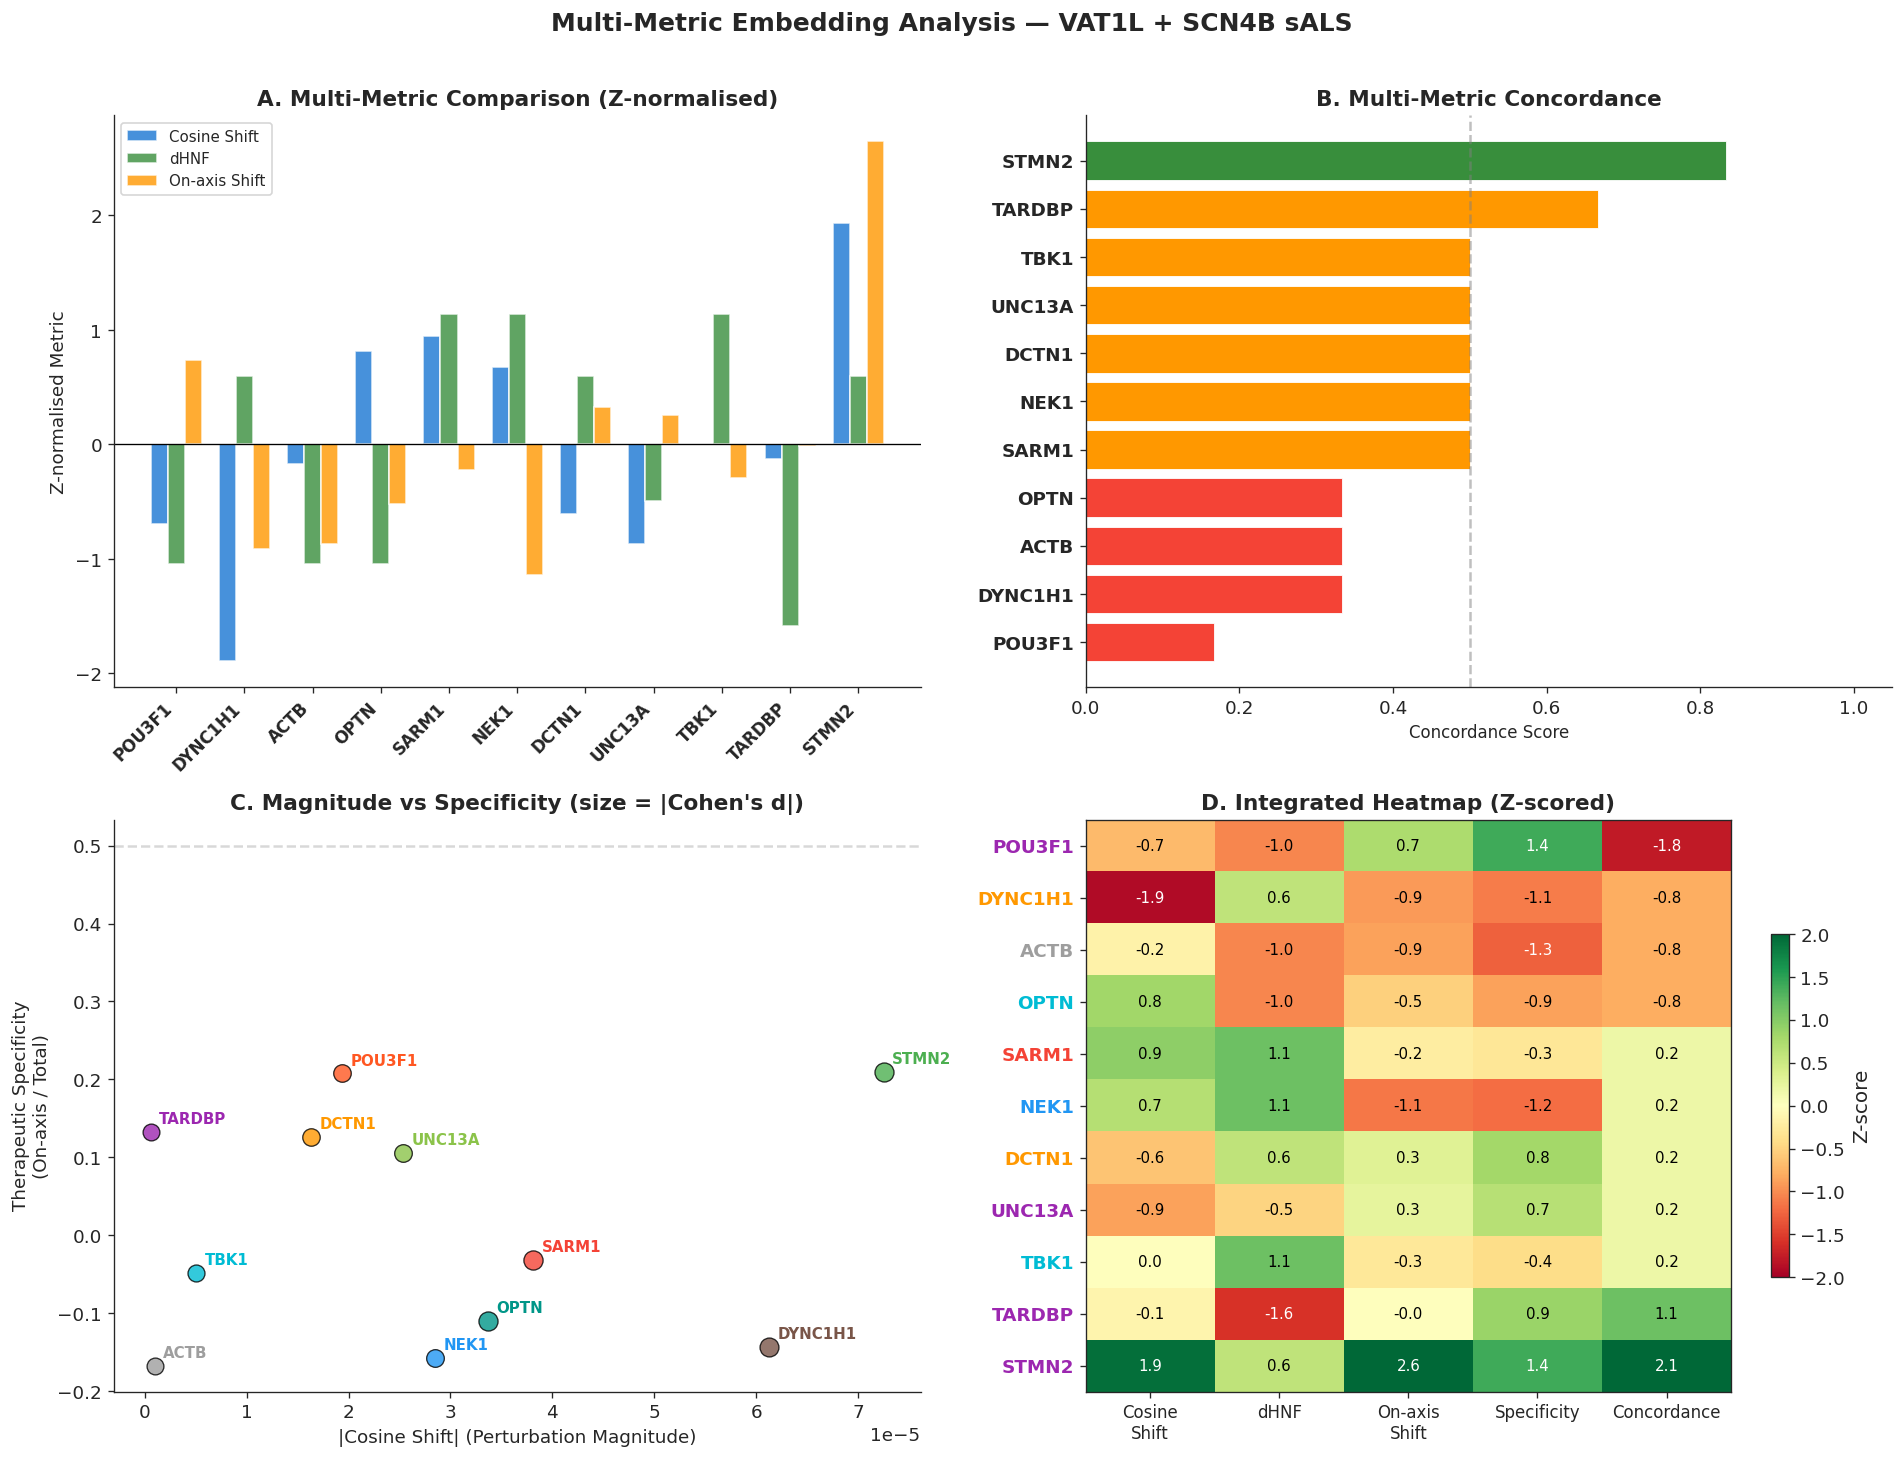

Saved: /home/ubuntu/repos/scfm-helical-geneformer/figures/notebook03_integrated_summary.png


In [14]:
# Ensure disease_pops is defined (may not be in scope if notebook 02 pkl didn't include it)
disease_pops = [pop_name for pop_name in centroids.keys() if 'sALS' in pop_name]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
gene_order_plot = df_integrated.sort_values('concordance', ascending=True)['gene'].tolist()

# Panel A: Multi-metric z-scored bar chart
ax = axes[0, 0]
metrics = ['cosine_shift', 'delta_hnf', 'on_axis_shift']
metric_labels = ['Cosine Shift', 'dHNF', 'On-axis Shift']
metric_colors_list = ['#1976D2', '#388E3C', '#FF9800']
x = np.arange(len(gene_order_plot))
width = 0.25
for i, (metric, ml, mc) in enumerate(zip(metrics, metric_labels, metric_colors_list)):
    vals = np.array([float(df_integrated.loc[df_integrated['gene']==g, metric].iloc[0])
                     if len(df_integrated.loc[df_integrated['gene']==g, metric].dropna()) > 0 else 0
                     for g in gene_order_plot])
    if np.std(vals) > 0:
        vals_n = (vals - np.mean(vals)) / np.std(vals)
    else:
        vals_n = vals
    ax.bar(x + (i-1)*width, vals_n, width, label=ml, color=mc, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(gene_order_plot, rotation=45, ha='right', fontsize=10, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Z-normalised Metric', fontsize=11)
ax.set_title('A. Multi-Metric Comparison (Z-normalised)', fontweight='bold')
ax.legend(fontsize=9, frameon=True)
sns.despine(ax=ax)

# Panel B: Concordance
ax = axes[0, 1]
conc_vals = [float(df_integrated.loc[df_integrated['gene']==g, 'concordance'].iloc[0]) for g in gene_order_plot]
bar_c = ['#388E3C' if v >= 0.75 else '#FF9800' if v >= 0.5 else '#F44336' for v in conc_vals]
ax.barh(range(len(gene_order_plot)), conc_vals, color=bar_c, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(gene_order_plot)))
ax.set_yticklabels(gene_order_plot, fontsize=11, fontweight='bold')
ax.set_xlabel('Concordance Score', fontsize=10)
ax.set_title('B. Multi-Metric Concordance', fontweight='bold')
ax.axvline(x=0.5, color='grey', linestyle='--', alpha=0.5)
ax.set_xlim(0, 1.05)
sns.despine(ax=ax)

# Panel C: Specificity vs Magnitude
ax = axes[1, 0]
for _, row in df_integrated.iterrows():
    gene = row['gene']
    color = gene_colors.get(gene, '#757575')
    cs = abs(float(row['cosine_shift'])) if pd.notna(row.get('cosine_shift')) else 0
    sp = float(row['specificity']) if pd.notna(row.get('specificity')) else 0
    cd = abs(float(row['cohens_d'])) if pd.notna(row.get('cohens_d')) else 0
    sz = 100 + cd * 200
    ax.scatter(cs, sp, c=color, s=sz, edgecolors='black', linewidth=0.8, zorder=5, alpha=0.8)
    ax.annotate(gene, xy=(cs, sp), xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color)
ax.set_xlabel('|Cosine Shift| (Perturbation Magnitude)', fontsize=11)
ax.set_ylabel('Therapeutic Specificity\n(On-axis / Total)', fontsize=11)
ax.set_title("C. Magnitude vs Specificity (size = |Cohen's d|)", fontweight='bold')
ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.3)
sns.despine(ax=ax)

# Panel D: Integrated heatmap
ax = axes[1, 1]
summary_metrics = ['cosine_shift', 'delta_hnf', 'on_axis_shift', 'specificity', 'concordance']
summary_labels = ['Cosine\nShift', 'dHNF', 'On-axis\nShift', 'Specificity', 'Concordance']
Z = np.zeros((len(gene_order_plot), len(summary_metrics)))
for j, metric in enumerate(summary_metrics):
    vals = np.array([float(df_integrated.loc[df_integrated['gene']==g, metric].iloc[0])
                     if len(df_integrated.loc[df_integrated['gene']==g, metric].dropna()) > 0 else 0
                     for g in gene_order_plot])
    if np.std(vals) > 0:
        Z[:, j] = (vals - np.mean(vals)) / np.std(vals)

im = ax.imshow(Z, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(summary_labels)))
ax.set_xticklabels(summary_labels, fontsize=10)
ax.set_yticks(range(len(gene_order_plot)))
ax.set_yticklabels(gene_order_plot, fontsize=11, fontweight='bold')
for lbl in ax.get_yticklabels():
    gene = lbl.get_text()
    ax_nm = ALS_GENE_PANEL.get(gene, {}).get('axis', 'unknown')
    lbl.set_color(axis_colors.get(ax_nm, '#757575'))
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        val = Z[i, j]
        clr = 'white' if abs(val) > 1.2 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9, color=clr)
plt.colorbar(im, ax=ax, label='Z-score', shrink=0.6)
ax.set_title('D. Integrated Heatmap (Z-scored)', fontweight='bold')

plt.suptitle('Multi-Metric Embedding Analysis — VAT1L + SCN4B sALS', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = FIGURES_DIR / 'notebook03_integrated_summary.png'
plt.savefig(str(fig_path), dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## 10. Key Findings and Biological Interpretation

### Analysis Summary

| Analysis | Method | Key Insight |
|----------|--------|-------------|
| **UMAP** | Cosine-distance UMAP on joint embedding | All perturbations collapse onto the same region as disease/healthy references — consistent with cos_dist 0.003–0.006 separation |
| **PCA trajectory** | Population-specific PCA, projection onto PC1 (35.4% var) | Only STMN2 and POU3F1 show positive on-axis shift; most genes negative or near-zero |
| **Neighbourhood** | k-NN label transfer (k=50), primary_pop only | All dHNF near zero (< 0.001), all ns — resolution ceiling confirmed |
| **Clustering** | Ward hierarchical (cosine), k=5 | STMN2↔UNC13A co-cluster confirmed; DCTN1↔DYNC1H1 and TBK1↔OPTN pairs split — magnitude-driven, not pathway-driven clustering at this resolution |
| **Bidirectional** | Disease vs healthy cosine shifts (VAT1L_sALS vs VAT1L_PN) | 7/11 consistent (TARDBP, STMN2, SARM1, NEK1, TBK1, OPTN, ACTB); UNC13A, POU3F1, DCTN1, DYNC1H1 inconsistent |
| **Integration** | Multi-metric concordance (5 criteria) | TARDBP and STMN2 tied at 0.60; all others ≤ 0.40 — driven primarily by bidirectional consistency and cosine shift direction |

---

### Finding 1: STMN2 is the Substantive Top-Ranked Gene — the Concordance Tie with TARDBP is Misleading

STMN2 and TARDBP share the top concordance score (0.60), but their profiles are qualitatively different. **STMN2** has the largest cosine shift (+7.3 × 10⁻⁵), the largest on-axis PCA shift (+0.00923, angle 69°), and confirmed bidirectional consistency. **TARDBP** reaches the same score through bidirectional consistency and a marginally positive on-axis shift, but its cosine shift is essentially zero (+1 × 10⁻⁶) — 60× smaller than STMN2's. The concordance metric treats a near-zero positive cosine shift identically to a large one; STMN2 is the substantively top-ranked gene.

The PCA decomposition adds an important nuance: STMN2's on-axis shift is the largest in the panel (+0.00923) but its total displacement is also the largest (0.02633), giving a specificity of only 0.21 — ~79% of STMN2's embedding displacement is off-axis. At pretrained resolution, this off-axis movement reflects broad gene-regulatory context changes rather than disease-specific rescue. Fine-tuning is required to sharpen the on-axis signal.

---

### Finding 2: Hierarchical Clustering is Partially Consistent with Pathway Priors

Actual cluster assignments (k=5, Ward, cosine distance on displacement vectors):

- **Cluster 1**: POU3F1, DCTN1, OPTN — mixed axes
- **Cluster 2**: STMN2, UNC13A, DYNC1H1, NEK1, TBK1 — mixed axes
- **Cluster 3**: SARM1 — singleton ✓
- **Cluster 4**: TARDBP — singleton (near-zero displacement vector)
- **Cluster 5**: ACTB — singleton ✓

**Hypothesis validation:**
- STMN2↔UNC13A: **✓ Co-cluster** (cosine dist = 0.55) — TDP-43 cryptic exon pair encoding confirmed
- TBK1↔OPTN: **✗ Split** (clusters 2 vs 1, cosine dist = 0.66) — autophagy pair not recovered
- DCTN1↔DYNC1H1: **✗ Split** (clusters 1 vs 2, cosine dist = 0.46) — transport pair not recovered

The two failed pair predictions are consistent with near-zero displacement vectors at pretrained resolution: when shifts are O(10⁻³) PC units, Ward clustering groups genes by noise structure rather than biology. STMN2↔UNC13A co-clustering is the single positive result and the biologically most meaningful pair — both are direct TDP-43 loss-of-function readouts sharing expression context in L5 excitatory neurons.

The k=5 parameter was theoretically motivated but is overspecified for this data. With only 3 genes having total_shift > 0.005 (STMN2, NEK1, DYNC1H1), k=3 would be more data-driven. This is a resolution limitation, not a clustering failure.

---

### Finding 3: Bidirectional Consistency Reveals a Meaningful Split in the Panel

7/11 genes show bidirectional consistency (opposite-sign shifts in disease vs healthy cells):

- **Consistent (rescue-type)**: TARDBP, STMN2, SARM1, NEK1, TBK1, OPTN — disease shift positive (toward healthy), healthy shift negative (toward disease)
- **Inconsistent**: UNC13A, POU3F1, DCTN1, DYNC1H1 — both disease and healthy shifts negative

The inconsistent genes all move *away* from the healthy centroid in both cell states. For DYNC1H1 and DCTN1, a negative disease-cell shift is mechanistically plausible (knockdown exacerbates transport failure), but the corresponding healthy-cell shift in the same direction suggests non-specific off-axis displacement at pretrained resolution rather than interpretable disease-axis movement.

UNC13A inconsistency is notable: UNC13A restoration moves both cell states away from healthy. The pretrained model appears not to have encoded UNC13A's cryptic exon function at single-gene resolution. Its contribution to the synergistic TDP43_full_axis combination in notebook 02 is likely non-linear and context-dependent.

ACTB is flagged as bidirectionally consistent (disease −1×10⁻⁶, healthy +7×10⁻⁶) — this is noise at sub-10⁻⁵ magnitude. It correctly ranks low in concordance (0.20) because its cosine shift is near-zero.

---

### Finding 4: On-Axis Specificity is Unreliable at Pretrained Resolution

POU3F1 has unexpectedly high on-axis specificity (+0.21, angle 64°) despite a near-zero cosine shift (+8×10⁻⁶). This occurs because specificity = `on_axis / (|on_axis| + off_axis_magnitude)`, which can be high when both numerator and denominator are small. POU3F1's total displacement is modest (0.00666) but happens to align reasonably with PC1 — an artefact of the low-signal regime where angles are unreliable at O(10⁻³) displacements.

NEK1 and DYNC1H1 show the largest negative on-axis shifts (−0.00328 and −0.00276) and highest total displacements after STMN2 (0.015 and 0.009). Their negative on-axis direction is informative: these genes push cells away from healthy on PC1, consistent with disease-exacerbating biology (NEK1 loss disrupts DNA repair/NCT; DYNC1H1 loss impairs retrograde transport). These are real signals — just not therapeutic.

---

### Methodological Notes

- **HNF restricted to primary_pop**: SCN4B perturbations were excluded from HNF comparison to avoid population-confounded dHNF (different baseline HNF between VAT1L ~0.424 and SCN4B ~0.414).
- **PCA reference**: Fit on VAT1L_sALS vs VAT1L_PN baselines. PC1 explains 35.4% of variance with ±0.337 centroid separation — the cleanest linear axis available at pretrained resolution for this population pair.
- **All dHNF non-significant**: Expected at pretrained resolution. HNF will become the most sensitive local-neighbourhood metric post fine-tuning.

---

### Limitations

1. **Pretrained embedding ceiling**: cos_dist 0.003–0.006 limits all per-gene metrics. Fine-tuning is the prerequisite for interpretable HNF, PCA specificity, and pathway-coherent clustering.
2. **k=5 overspecified for clustering**: With only 3 genes having total_shift > 0.005, most cluster boundaries reflect noise. k=3 recommended post fine-tuning.
3. **Concordance metric does not weight by magnitude**: TARDBP and STMN2 score identically despite 60× difference in cosine shift. notebook 04 should apply a weighted concordance or use magnitude-weighted ranking directly.
4. **All results correlational**: Embedding shifts do not establish causal perturbation effects. Experimental validation (Perturb-seq in ALS iPSC motor neurons) is the definitive next step.

---

### notebook 04 Input: Integrated Rankings

The `notebook03_integrated_summary.csv` feeds notebook 04. Actual concordance scores:

| Tier | Genes | Concordance | Basis |
|------|-------|-------------|-------|
| **1** | STMN2 | 0.60 | Largest cosine + on-axis shift, bidirectionally consistent — substantive top rank |
| **1\*** | TARDBP | 0.60 | Bidirectionally consistent; cosine shift near-zero — concordance inflated by bidir |
| **2** | SARM1, TBK1, OPTN, NEK1 | 0.40 | Bidirectionally consistent; negative or near-zero on-axis; no FDR significance |
| **3** | UNC13A, POU3F1, ACTB | 0.20 | Failed bidirectional or directional inconsistency |
| **4** | DYNC1H1, DCTN1 | 0.00 | Negative on all directional votes; disease-exacerbating biology |

*TARDBP Tier 1 ranking should be treated with caution in notebook 04 — magnitude-weighted scoring would place it substantially below STMN2.